# Python Statistical Analytics - Comprehensive Practical Training Notebook

**Prepared by: Kajola Gbenga**
**Data Scientist & AI Engineer**

---

This notebook is a complete, line-by-line practical walkthrough of statistical analytics in Python.
It uses two companion data files that ship alongside this notebook:

1. `employee_statistics_dataset.csv` - a 400-row cross-sectional dataset (departments, demographics,
   training scores, performance, sales, satisfaction, promotion status) used for descriptive statistics,
   distributions, hypothesis testing, correlation, and regression.
2. `monthly_revenue_timeseries.csv` - a 60-month time series (revenue, marketing spend, units sold)
   used for the time-series analysis section.

The same two CSV files are also provided as sheets in the companion Excel workbook
`python_statistical_analytics_workbook.xlsx`, and the full theory is written out in the companion
Word document and HTML guide. Use all four together for training.

## Table of Contents
1. Environment Setup
2. Loading and Inspecting the Data
3. Data Cleaning - Missing Values, Duplicates, Data Types
4. Descriptive (Summary) Statistics
5. Measures of Shape - Skewness and Kurtosis
6. Data Visualization for Statistics
7. Probability Distributions
8. Sampling and the Central Limit Theorem
9. Confidence Intervals
10. Hypothesis Testing - One-Sample and Two-Sample Tests
11. Paired-Samples Test
12. Analysis of Variance (ANOVA) - One-Way and Two-Way
13. Non-Parametric Tests
14. Tests of Normality and Equal Variance
15. Effect Size
16. Correlation Analysis
17. Chi-Square Tests for Categorical Data
18. Simple and Multiple Linear Regression
19. Regression Diagnostics and Multicollinearity
20. Logistic Regression
21. Statistical Power and Sample Size
22. Bootstrapping and Resampling
23. Bayesian Statistics - A Practical Introduction
24. Time Series Analysis
25. Cheat Sheet and Reference Summary
26. Conclusion


## 1. Environment Setup

We import every library used in this notebook in one place. Line-by-line:

- `numpy` - numerical arrays and vectorised math.
- `pandas` - tabular data handling (DataFrames).
- `scipy.stats` - the core statistical-tests and probability-distribution library.
- `statsmodels.api` / `statsmodels.formula.api` - regression models, ANOVA tables, diagnostics.
- `matplotlib.pyplot` and `seaborn` - plotting.
- `sklearn` - machine-learning-flavoured regression/classification utilities used for comparison.
- `warnings` - silence noisy library warnings so the notebook output stays readable.


In [1]:
# Core numerical and data-handling libraries
import numpy as np                      # array math, random number generation
import pandas as pd                     # DataFrame / Series data structures

# Statistics engines
import scipy.stats as stats             # hypothesis tests, distributions, descriptive stats
import statsmodels.api as sm            # regression models, statistical tables
import statsmodels.formula.api as smf   # R-style formula interface for regression/ANOVA
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF for multicollinearity
from statsmodels.stats.diagnostic import het_breuschpagan                    # heteroscedasticity test
from statsmodels.stats.power import TTestIndPower                            # power analysis
from statsmodels.tsa.seasonal import seasonal_decompose                      # time series decomposition
from statsmodels.tsa.stattools import adfuller, acf, pacf                    # stationarity, ACF/PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf                # ACF/PACF plots

# Machine-learning-flavoured helpers (used for comparison with statsmodels)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")   # keep the training notebook's output clean

# Global plotting style used throughout the notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Reproducibility for any random sampling done inside this notebook
RNG = np.random.default_rng(42)

print("Libraries loaded successfully.")
print("numpy:", np.__version__, "| pandas:", pd.__version__, "| scipy:", stats.__name__)


Libraries loaded successfully.
numpy: 2.3.1 | pandas: 2.3.1 | scipy: scipy.stats


## 2. Loading and Inspecting the Data

We load the cross-sectional dataset first. Line-by-line:

- `pd.read_csv(...)` reads the CSV into a DataFrame.
- `.shape` reports (rows, columns).
- `.head()` previews the first 5 rows.
- `.info()` shows column data types and non-null counts - the fastest way to spot missing data.
- `.describe(include="all")` gives a first-pass summary of every column, numeric and categorical.


In [2]:
# Load the main cross-sectional dataset
df = pd.read_csv("employee_statistics_dataset.csv")

print("Shape of dataset (rows, columns):", df.shape)
df.head()


Shape of dataset (rows, columns): (400, 15)


,EmployeeID,Department,Gender,Region,Education,Age,YearsExperience,TrainingHours,PreTrainingScore,PostTrainingScore,PerformanceScore,MonthlySales,SatisfactionScore,AttendanceRate,Promoted
0,EMP1000,Marketing,Male,South,Bachelors,27,4.7,42.0,67.2,80.4,89.1,5566.48,7.0,94.8,1
1,EMP1001,Engineering,Female,North,Bachelors,30,6.4,32.3,61.1,74.5,75.8,4573.74,8.0,94.7,1
2,EMP1002,Operations,Female,West,Masters,29,3.4,36.7,47.4,57.5,72.5,4925.33,8.0,91.2,1
3,EMP1003,Marketing,Male,South,Masters,24,2.3,37.2,58.3,64.5,75.5,5995.71,8.0,90.0,0
4,EMP1004,Sales,Female,North,Diploma,21,3.0,31.2,73.8,80.8,91.0,4875.20,6.0,82.1,0


In [3]:
# Column data types and non-null counts - the fastest way to spot missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EmployeeID         400 non-null    object 
 1   Department         400 non-null    object 
 2   Gender             400 non-null    object 
 3   Region             400 non-null    object 
 4   Education          394 non-null    object 
 5   Age                400 non-null    int64  
 6   YearsExperience    400 non-null    float64
 7   TrainingHours      388 non-null    float64
 8   PreTrainingScore   400 non-null    float64
 9   PostTrainingScore  400 non-null    float64
 10  PerformanceScore   400 non-null    float64
 11  MonthlySales       400 non-null    float64
 12  SatisfactionScore  390 non-null    float64
 13  AttendanceRate     392 non-null    float64
 14  Promoted           400 non-null    int64  
dtypes: float64(8), int64(2), object(5)
memory usage: 47.0+ KB


In [4]:
# describe(include="all") summarises numeric AND categorical columns in one call
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeID,400,400,EMP1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,400,4,Engineering,123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,400,2,Male,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,400,3,North,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,394,4,Bachelors,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,400.0,NaN,NaN,NaN,31.0175,5.885047,21.0,27.0,30.0,35.0,49.0
YearsExperience,400.0,NaN,NaN,NaN,5.495,3.115476,0.0,3.2,5.5,7.6,15.3
TrainingHours,388.0,NaN,NaN,NaN,40.520103,11.901068,5.0,33.125,41.2,47.525,74.3
PreTrainingScore,400.0,NaN,NaN,NaN,59.85575,10.167606,33.7,52.6,59.5,66.325,88.5
PostTrainingScore,400.0,NaN,NaN,NaN,67.92775,10.896724,39.3,60.775,67.95,74.425,100.0


## 3. Data Cleaning - Missing Values, Duplicates, Data Types

No real statistical analysis is trustworthy on dirty data. We check, in order:

1. **Missing values** - count and percentage per column.
2. **Duplicate rows.**
3. **Outlier screening** using the IQR rule and the Z-score rule (both explained below).
4. **Missing-value handling strategies** - listwise deletion vs. mean/median/mode imputation.


In [5]:
# 3.1 Missing values: count and percentage per column
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing_count, "missing_percent": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_report


,missing_count,missing_percent
TrainingHours,12,3.0
SatisfactionScore,10,2.5
AttendanceRate,8,2.0
Education,6,1.5


In [6]:
# 3.2 Duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [7]:
# 3.3 Outlier screening on MonthlySales using the IQR rule
# The IQR rule: any point below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is flagged as an outlier.
q1 = df["MonthlySales"].quantile(0.25)
q3 = df["MonthlySales"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

iqr_outliers = df[(df["MonthlySales"] < lower_bound) | (df["MonthlySales"] > upper_bound)]
print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"IQR fence: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of IQR outliers in MonthlySales: {len(iqr_outliers)}")
iqr_outliers[["EmployeeID", "Department", "MonthlySales"]]


Q1=5353.09, Q3=7240.37, IQR=1887.29
IQR fence: [2522.15, 10071.30]
Number of IQR outliers in MonthlySales: 8


,EmployeeID,Department,MonthlySales
103,EMP1103,Operations,10755.080000
115,EMP1115,Operations,2159.960000
266,EMP1266,Sales,38815.792427
309,EMP1309,Sales,24729.838214
315,EMP1315,Engineering,2421.040000
319,EMP1319,Operations,23113.164617
352,EMP1352,Engineering,35453.722716
396,EMP1396,Operations,38170.443887


In [8]:
# 3.4 Outlier screening using the Z-score rule
# The Z-score rule: any point with |z| > 3 (more than 3 standard deviations from the mean) is flagged.
z_scores = np.abs(stats.zscore(df["MonthlySales"], nan_policy="omit"))
z_outliers = df[z_scores > 3]
print(f"Number of Z-score (|z|>3) outliers in MonthlySales: {len(z_outliers)}")
z_outliers[["EmployeeID", "Department", "MonthlySales"]]


Number of Z-score (|z|>3) outliers in MonthlySales: 5


,EmployeeID,Department,MonthlySales
266,EMP1266,Sales,38815.792427
309,EMP1309,Sales,24729.838214
319,EMP1319,Operations,23113.164617
352,EMP1352,Engineering,35453.722716
396,EMP1396,Operations,38170.443887


In [9]:
# 3.5 Handling missing values - two common strategies

# Strategy A: listwise deletion (drop any row with at least one missing value)
df_listwise = df.dropna()
print("Rows after listwise deletion:", df_listwise.shape[0], "of", df.shape[0])

# Strategy B: imputation - numeric columns with median, categorical columns with mode
df_imputed = df.copy()
for col in ["TrainingHours", "SatisfactionScore", "AttendanceRate"]:
    median_val = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median_val)
    print(f"Imputed '{col}' missing values with median = {median_val:.2f}")

df_imputed["Education"] = df_imputed["Education"].fillna(df_imputed["Education"].mode()[0])
print("Imputed 'Education' missing values with mode =", df_imputed["Education"].mode()[0])

print("\nRemaining missing values after imputation:")
print(df_imputed.isna().sum().sum(), "total missing cells")

# From here on we use df_imputed as the primary working frame so every later
# calculation runs on the full 400 rows without NaN-related surprises.
df = df_imputed


Rows after listwise deletion: 367 of 400
Imputed 'TrainingHours' missing values with median = 41.20
Imputed 'SatisfactionScore' missing values with median = 7.00
Imputed 'AttendanceRate' missing values with median = 92.85
Imputed 'Education' missing values with mode = Bachelors

Remaining missing values after imputation:
0 total missing cells


## 4. Descriptive (Summary) Statistics

Descriptive statistics summarise a dataset's central tendency, spread, and shape.

| Concept | What it measures | Python |
|---|---|---|
| Mean | Arithmetic average | `Series.mean()` |
| Median | Middle value (50th percentile) | `Series.median()` |
| Mode | Most frequent value | `Series.mode()` |
| Variance | Average squared deviation from the mean | `Series.var()` |
| Standard deviation | Square root of variance, same units as the data | `Series.std()` |
| Range | Max − Min | `Series.max() - Series.min()` |
| Percentile / Quantile | Value below which a given % of data falls | `Series.quantile(q)` |
| Interquartile Range (IQR) | Q3 − Q1, spread of the middle 50% | manual, shown below |
| Coefficient of variation | Std / Mean, relative spread | manual, shown below |

We compute all of these, column by column, for every numeric variable.


In [10]:
numeric_cols = ["Age", "YearsExperience", "TrainingHours", "PreTrainingScore",
                "PostTrainingScore", "PerformanceScore", "MonthlySales",
                "SatisfactionScore", "AttendanceRate"]

def full_descriptive_summary(series):
    # Return a dict of the standard descriptive statistics for one numeric Series.
    return {
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0] if not series.mode().empty else np.nan,
        "std_dev": series.std(),                 # sample standard deviation (ddof=1 by default)
        "variance": series.var(),                # sample variance (ddof=1 by default)
        "min": series.min(),
        "max": series.max(),
        "range": series.max() - series.min(),
        "q1_25pct": series.quantile(0.25),
        "q3_75pct": series.quantile(0.75),
        "iqr": series.quantile(0.75) - series.quantile(0.25),
        "coeff_of_variation_%": (series.std() / series.mean()) * 100,
    }

summary_table = pd.DataFrame({col: full_descriptive_summary(df[col]) for col in numeric_cols}).T
summary_table.round(2)


,count,mean,median,mode,std_dev,variance,min,max,range,q1_25pct,q3_75pct,iqr,coeff_of_variation_%
Age,400.0,31.02,30.00,28.00,5.89,34.63,21.00,49.00,28.00,27.00,35.00,8.00,18.97
YearsExperience,400.0,5.50,5.50,0.00,3.12,9.71,0.00,15.30,15.30,3.20,7.60,4.40,56.70
TrainingHours,400.0,40.54,41.20,41.20,11.72,137.39,5.00,74.30,69.30,33.58,47.30,13.72,28.91
PreTrainingScore,400.0,59.86,59.50,58.30,10.17,103.38,33.70,88.50,54.80,52.60,66.32,13.73,16.99
PostTrainingScore,400.0,67.93,67.95,58.90,10.90,118.74,39.30,100.00,60.70,60.78,74.43,13.65,16.04
PerformanceScore,400.0,81.38,81.70,100.00,10.26,105.22,57.90,100.00,42.10,74.35,89.40,15.05,12.60
MonthlySales,400.0,6587.51,6269.75,2159.96,3256.28,10603344.00,2159.96,38815.79,36655.83,5353.08,7240.37,1887.29,49.43
SatisfactionScore,400.0,6.98,7.00,7.00,1.52,2.31,3.00,10.00,7.00,6.00,8.00,2.00,21.74
AttendanceRate,400.0,92.67,92.85,100.00,4.60,21.12,77.30,100.00,22.70,89.57,95.90,6.33,4.96


**Reading the table:** `PerformanceScore` has a mean close to its median, suggesting a roughly
symmetric distribution, while `MonthlySales` - which we deliberately seeded with outliers - has a
mean noticeably pulled above its median, a classic sign of right-skew driven by a few large values.

## 5. Measures of Shape - Skewness and Kurtosis

- **Skewness** measures asymmetry. `0` = symmetric, `>0` = right (positive) tail, `<0` = left (negative) tail.
- **Kurtosis** (excess kurtosis, as reported by `scipy`/`pandas`) measures tail-heaviness relative to a
  normal distribution. `0` = normal-like tails, `>0` = heavier tails (leptokurtic), `<0` = lighter tails
  (platykurtic).


In [11]:
shape_table = pd.DataFrame({
    "skewness": {c: stats.skew(df[c].dropna()) for c in numeric_cols},
    "kurtosis_excess": {c: stats.kurtosis(df[c].dropna()) for c in numeric_cols},
})
shape_table.round(3)


,skewness,kurtosis_excess
Age,0.248,-0.489
YearsExperience,0.189,-0.339
TrainingHours,-0.055,0.502
PreTrainingScore,0.196,-0.121
PostTrainingScore,0.104,-0.073
PerformanceScore,-0.236,-0.643
MonthlySales,7.176,63.047
SatisfactionScore,-0.160,-0.411
AttendanceRate,-0.446,0.090


## 6. Data Visualization for Statistics

A picture of the distribution is as important as the numbers. We build, in turn:

1. Histogram + KDE (shape of the distribution).
2. Boxplot (median, quartiles, whiskers, outliers).
3. Violin plot (distribution shape across groups).
4. Scatter plot (relationship between two continuous variables).
5. Pair plot (all pairwise relationships at once).
6. Correlation heatmap.
7. Q-Q plot (visual normality check).
8. Bar chart of a categorical variable.


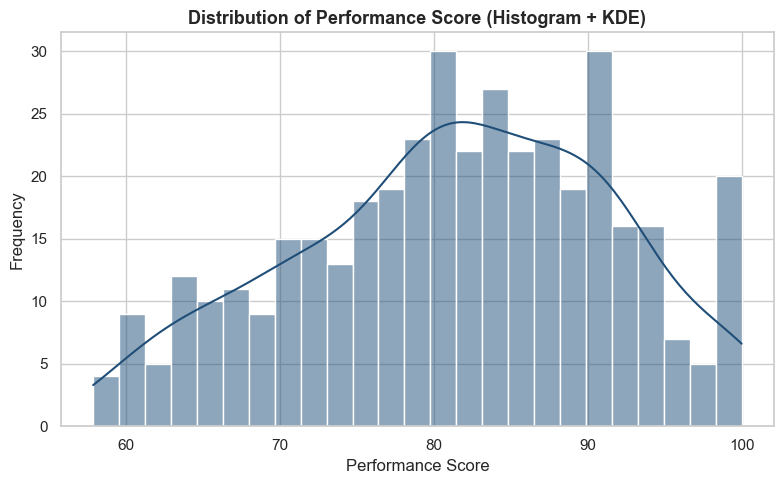

In [12]:
# 6.1 Histogram + KDE for PerformanceScore
fig, ax = plt.subplots()
sns.histplot(df["PerformanceScore"], kde=True, bins=25, color="#1F4E78", ax=ax)
ax.set_title("Distribution of Performance Score (Histogram + KDE)")
ax.set_xlabel("Performance Score")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


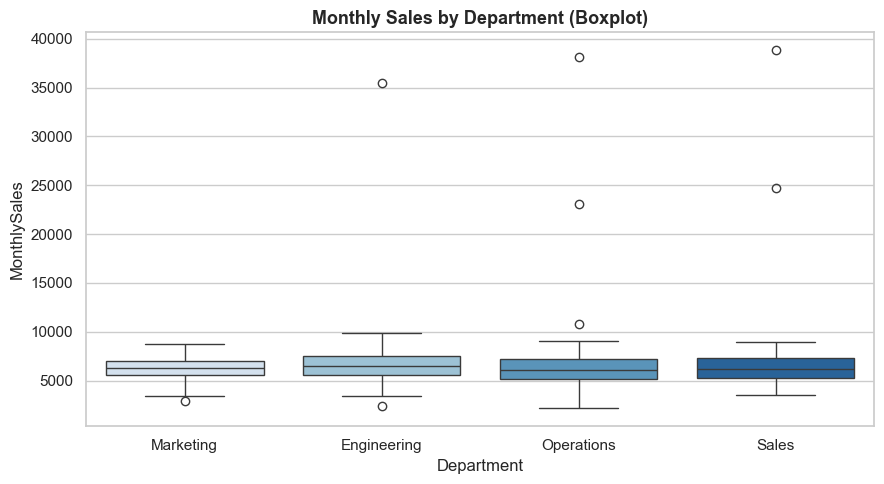

In [13]:
# 6.2 Boxplot of MonthlySales by Department - shows median, IQR box, whiskers, and outlier points
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Department", y="MonthlySales", ax=ax, palette="Blues")
ax.set_title("Monthly Sales by Department (Boxplot)")
plt.tight_layout()
plt.show()


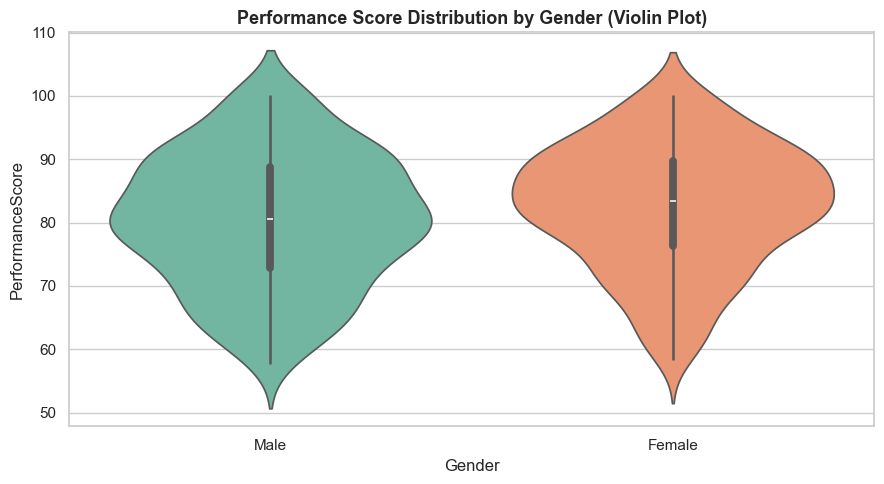

In [14]:
# 6.3 Violin plot - combines a boxplot with a rotated KDE to show the full distribution shape per group
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x="Gender", y="PerformanceScore", ax=ax, palette="Set2")
ax.set_title("Performance Score Distribution by Gender (Violin Plot)")
plt.tight_layout()
plt.show()


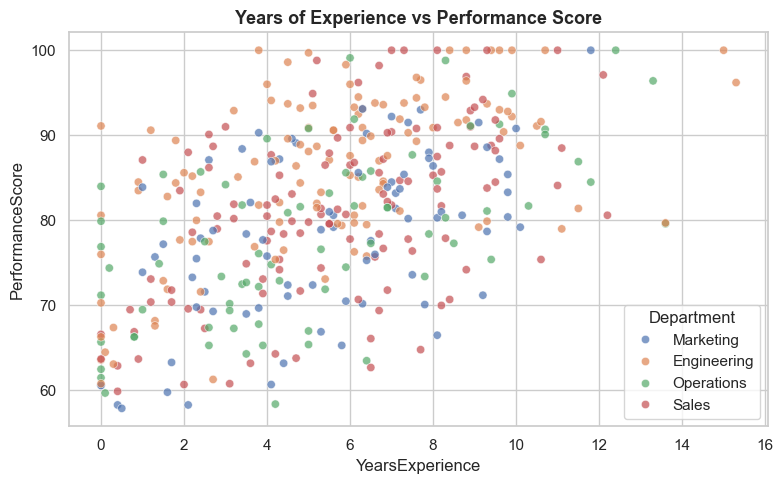

In [15]:
# 6.4 Scatter plot - relationship between YearsExperience and PerformanceScore
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="YearsExperience", y="PerformanceScore", hue="Department", ax=ax, alpha=0.7)
ax.set_title("Years of Experience vs Performance Score")
plt.tight_layout()
plt.show()


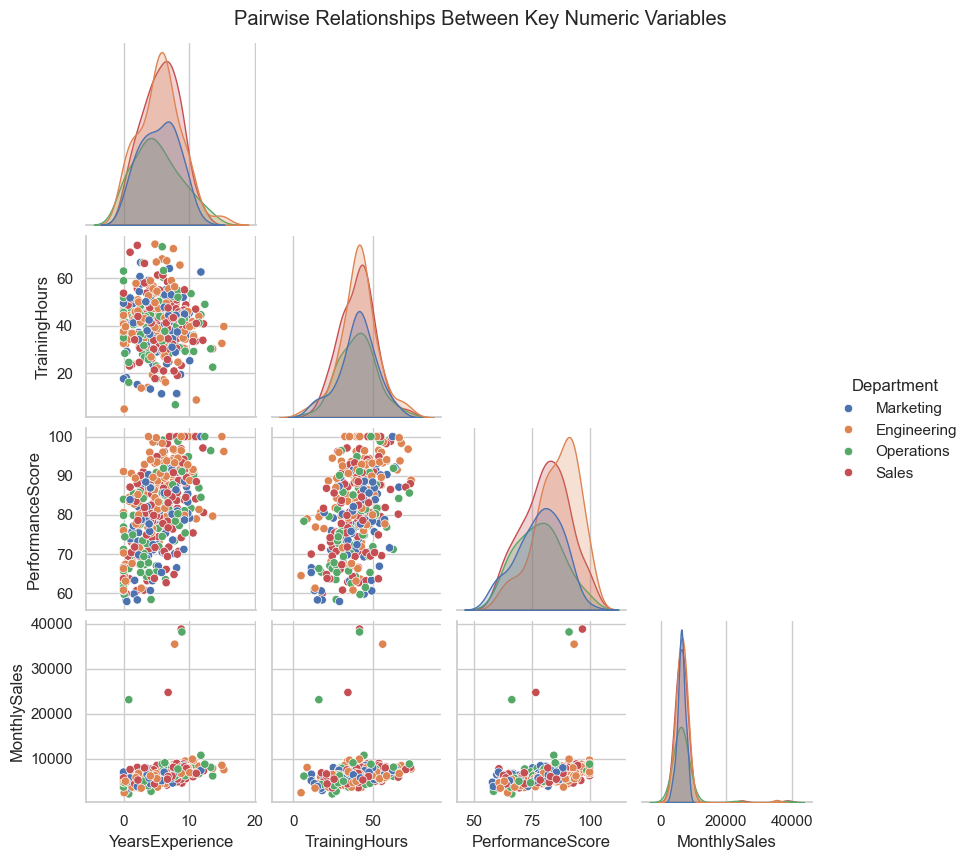

In [16]:
# 6.5 Pair plot - all pairwise scatter relationships + individual histograms in one grid
pair_cols = ["YearsExperience", "TrainingHours", "PerformanceScore", "MonthlySales"]
sns.pairplot(df[pair_cols + ["Department"]], hue="Department", corner=True, height=2.1)
plt.suptitle("Pairwise Relationships Between Key Numeric Variables", y=1.02)
plt.show()


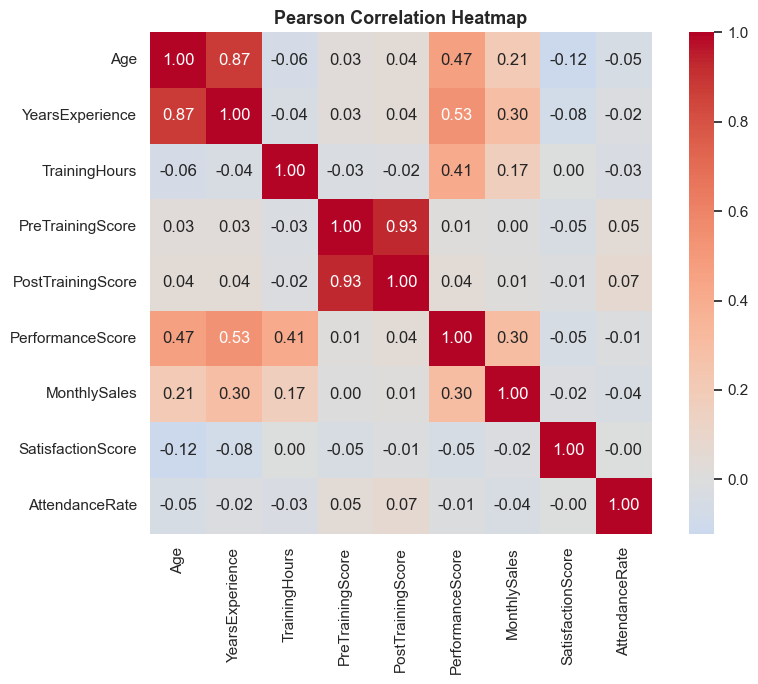

In [17]:
# 6.6 Correlation heatmap across all numeric columns
corr_matrix = df[numeric_cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()


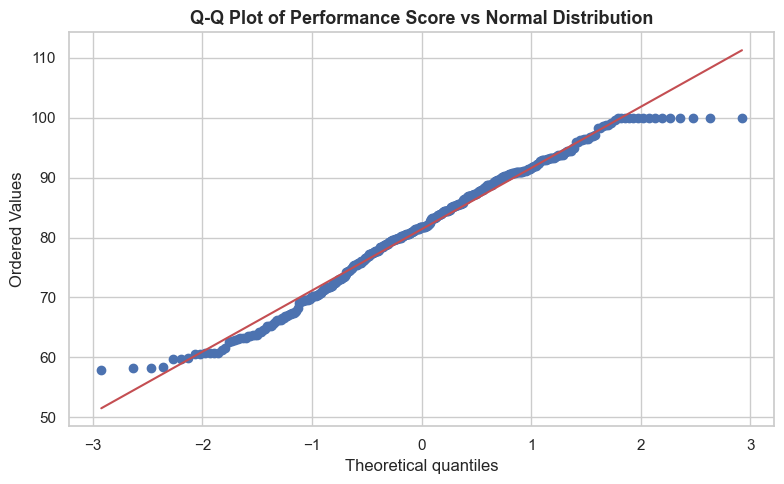

In [18]:
# 6.7 Q-Q (quantile-quantile) plot - visually checks whether a variable follows a normal distribution.
# Points lying on the diagonal red line indicate approximate normality.
fig, ax = plt.subplots()
stats.probplot(df["PerformanceScore"], dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Performance Score vs Normal Distribution")
plt.tight_layout()
plt.show()


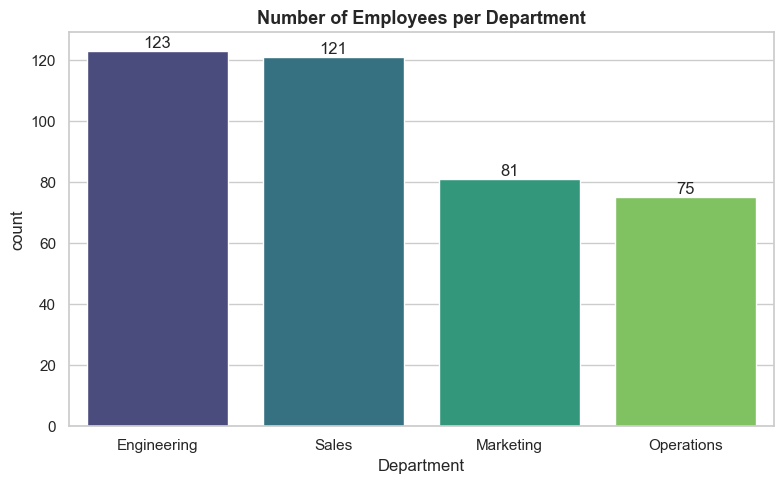

In [19]:
# 6.8 Bar chart of a categorical variable - counts per Department
fig, ax = plt.subplots()
order = df["Department"].value_counts().index
sns.countplot(data=df, x="Department", order=order, palette="viridis", ax=ax)
ax.set_title("Number of Employees per Department")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


## 7. Probability Distributions

`scipy.stats` implements every classical distribution with a common interface:
`.pdf()` / `.pmf()` (density/mass), `.cdf()` (cumulative probability), `.ppf()` (inverse CDF / quantile
function), and `.rvs()` (random sampling). We walk through the distributions most used in practice.


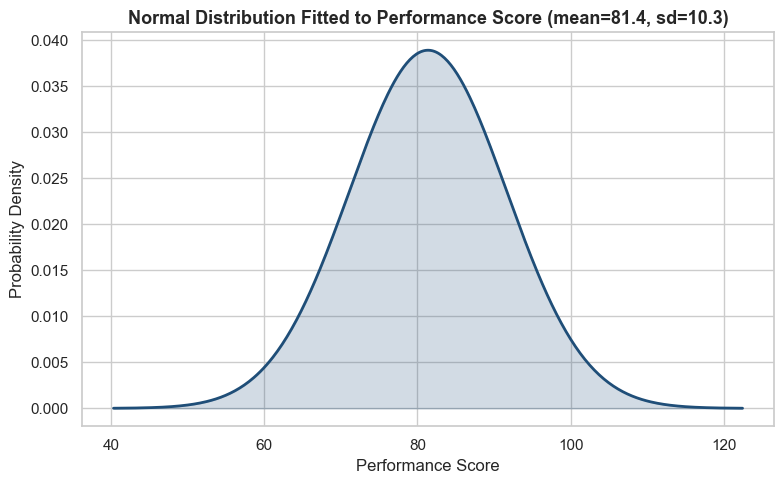

P(PerformanceScore > 90)  = 0.2004
P(PerformanceScore < 60)  = 0.0186
Score marking the top 10% = 94.53


In [20]:
# 7.1 Normal (Gaussian) distribution - the workhorse continuous distribution
mu, sigma = df["PerformanceScore"].mean(), df["PerformanceScore"].std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf_vals = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots()
ax.plot(x, pdf_vals, color="#1F4E78", lw=2)
ax.fill_between(x, pdf_vals, alpha=0.2, color="#1F4E78")
ax.set_title(f"Normal Distribution Fitted to Performance Score (mean={mu:.1f}, sd={sigma:.1f})")
ax.set_xlabel("Performance Score"); ax.set_ylabel("Probability Density")
plt.tight_layout(); plt.show()

# Key normal-distribution probability questions, answered with .cdf() and .ppf()
p_above_90 = 1 - stats.norm.cdf(90, loc=mu, scale=sigma)
p_below_60 = stats.norm.cdf(60, loc=mu, scale=sigma)
score_top_10pct = stats.norm.ppf(0.90, loc=mu, scale=sigma)
print(f"P(PerformanceScore > 90)  = {p_above_90:.4f}")
print(f"P(PerformanceScore < 60)  = {p_below_60:.4f}")
print(f"Score marking the top 10% = {score_top_10pct:.2f}")


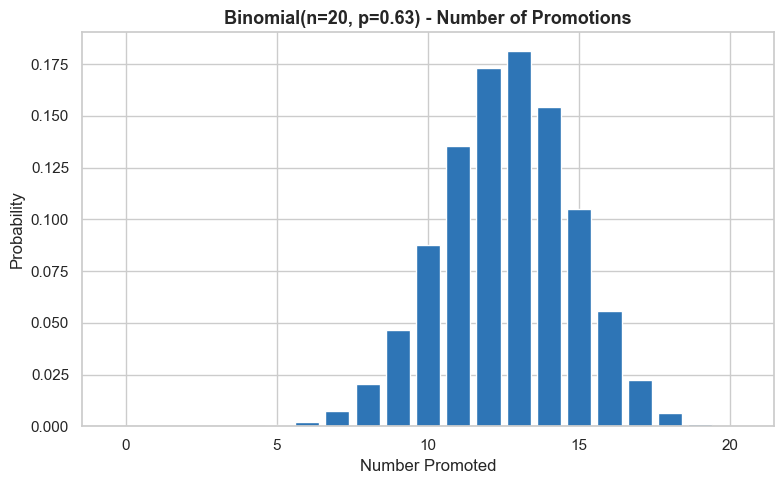

P(exactly 5 promoted out of 20)     = 0.0005
P(at most 3 promoted out of 20)     = 0.0000
P(more than 8 promoted out of 20)   = 0.9692


In [21]:
# 7.2 Binomial distribution - number of successes in n independent yes/no trials
# Example: probability of exactly k promotions out of 20 employees, given the sample promotion rate
n_trials = 20
p_success = df["Promoted"].mean()
k = np.arange(0, n_trials + 1)
pmf_vals = stats.binom.pmf(k, n=n_trials, p=p_success)

fig, ax = plt.subplots()
ax.bar(k, pmf_vals, color="#2E75B6")
ax.set_title(f"Binomial(n={n_trials}, p={p_success:.2f}) - Number of Promotions")
ax.set_xlabel("Number Promoted"); ax.set_ylabel("Probability")
plt.tight_layout(); plt.show()

print(f"P(exactly 5 promoted out of 20)     = {stats.binom.pmf(5, n_trials, p_success):.4f}")
print(f"P(at most 3 promoted out of 20)     = {stats.binom.cdf(3, n_trials, p_success):.4f}")
print(f"P(more than 8 promoted out of 20)   = {1 - stats.binom.cdf(8, n_trials, p_success):.4f}")


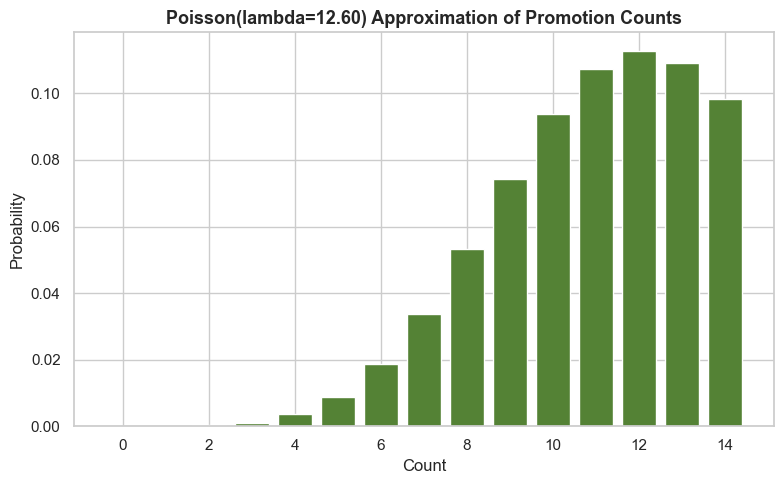

In [22]:
# 7.3 Poisson distribution - models counts of rare events in a fixed interval
# Example: number of promotions per 20-employee batch, modelled as a Poisson process
lam = n_trials * p_success   # expected count (lambda) matches the binomial mean above
k = np.arange(0, 15)
pmf_vals = stats.poisson.pmf(k, mu=lam)

fig, ax = plt.subplots()
ax.bar(k, pmf_vals, color="#548235")
ax.set_title(f"Poisson(lambda={lam:.2f}) Approximation of Promotion Counts")
ax.set_xlabel("Count"); ax.set_ylabel("Probability")
plt.tight_layout(); plt.show()


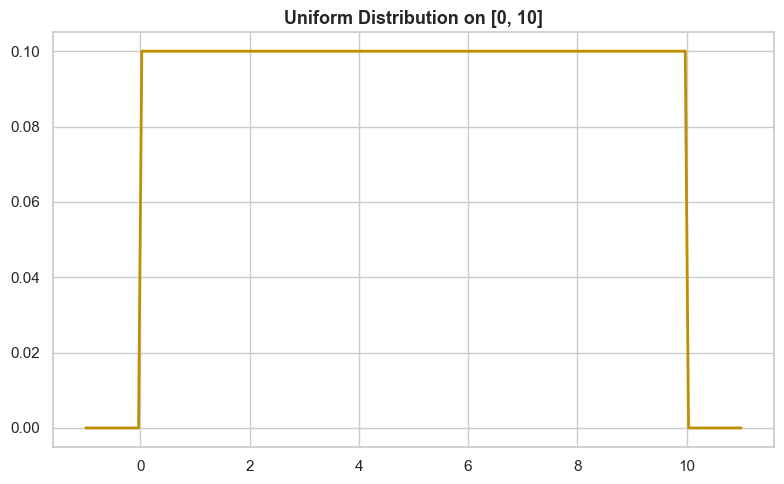

In [23]:
# 7.4 Uniform distribution - every value in [a, b] is equally likely
a, b = 0, 10
x = np.linspace(a - 1, b + 1, 200)
fig, ax = plt.subplots()
ax.plot(x, stats.uniform.pdf(x, loc=a, scale=b - a), color="#BF8F00", lw=2)
ax.set_title(f"Uniform Distribution on [{a}, {b}]")
plt.tight_layout(); plt.show()


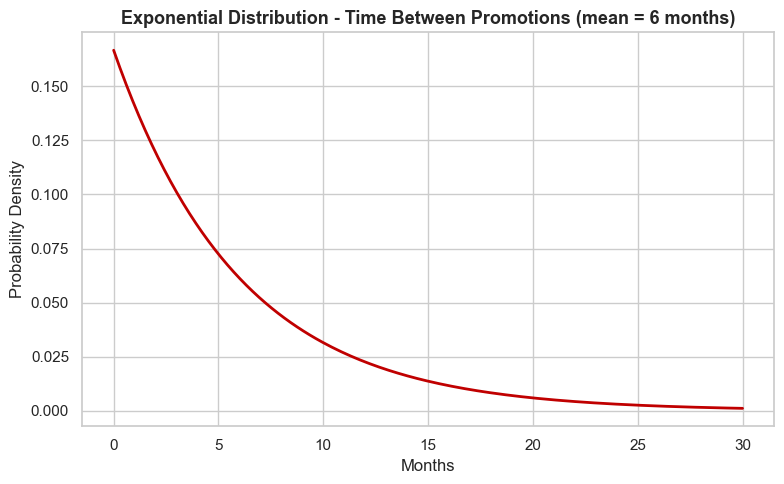

In [24]:
# 7.5 Exponential distribution - models waiting times between independent events
# Example: time (in months) between successive promotions, assuming a constant promotion rate
rate = 1 / 6   # assume an average of one promotion every 6 months per department
x = np.linspace(0, 30, 200)
fig, ax = plt.subplots()
ax.plot(x, stats.expon.pdf(x, scale=1/rate), color="#C00000", lw=2)
ax.set_title("Exponential Distribution - Time Between Promotions (mean = 6 months)")
ax.set_xlabel("Months"); ax.set_ylabel("Probability Density")
plt.tight_layout(); plt.show()


In [25]:
# 7.6 Fitting a distribution to real data
# stats.norm.fit() returns the maximum-likelihood mean and std that best fit the observed data
fitted_mu, fitted_sigma = stats.norm.fit(df["PerformanceScore"])
print(f"Best-fit Normal parameters for PerformanceScore: mean={fitted_mu:.2f}, sd={fitted_sigma:.2f}")
print(f"(Compare with the sample mean={df['PerformanceScore'].mean():.2f} and sd={df['PerformanceScore'].std():.2f} - "
      f"fit() uses the population, ddof=0, convention, which is why the sd differs slightly.)")


Best-fit Normal parameters for PerformanceScore: mean=81.38, sd=10.24
(Compare with the sample mean=81.38 and sd=10.26 - fit() uses the population, ddof=0, convention, which is why the sd differs slightly.)


## 8. Sampling and the Central Limit Theorem (CLT)

The CLT states that the sampling distribution of the mean approaches a Normal distribution as sample
size grows - **regardless of the shape of the original population**. We demonstrate this by repeatedly
drawing samples from the (right-skewed) `MonthlySales` column and plotting the distribution of the
sample means.


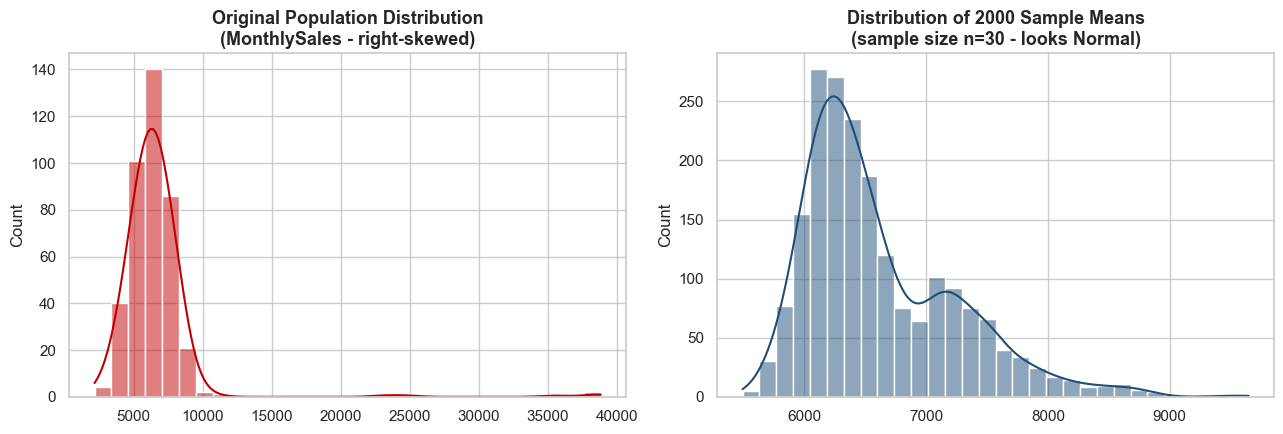

Population mean: 6587.51 | Mean of sample means: 6618.20
Population std:  3252.20 | Std of sample means (standard error): 626.14
Theoretical standard error (population_std / sqrt(n)): 593.77


In [26]:
population = df["MonthlySales"].values
sample_size = 30
n_samples = 2000

sample_means = [RNG.choice(population, size=sample_size, replace=True).mean() for _ in range(n_samples)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(population, kde=True, ax=axes[0], color="#C00000", bins=30)
axes[0].set_title("Original Population Distribution\n(MonthlySales - right-skewed)")

sns.histplot(sample_means, kde=True, ax=axes[1], color="#1F4E78", bins=30)
axes[1].set_title(f"Distribution of {n_samples} Sample Means\n(sample size n={sample_size} - looks Normal)")
plt.tight_layout(); plt.show()

print(f"Population mean: {population.mean():.2f} | Mean of sample means: {np.mean(sample_means):.2f}")
print(f"Population std:  {population.std():.2f} | Std of sample means (standard error): {np.std(sample_means):.2f}")
print(f"Theoretical standard error (population_std / sqrt(n)): {population.std()/np.sqrt(sample_size):.2f}")


## 9. Confidence Intervals

A confidence interval (CI) gives a range of plausible values for a population parameter. A 95% CI means:
if we repeated the sampling process many times, 95% of the intervals constructed this way would contain
the true population value.


In [27]:
# 9.1 Confidence interval for a mean, using the t-distribution (appropriate when population sd is unknown)
sample = df["PerformanceScore"].dropna()
n = len(sample)
mean = sample.mean()
sem = stats.sem(sample)                     # standard error of the mean
ci_95 = stats.t.interval(confidence=0.95, df=n - 1, loc=mean, scale=sem)

print(f"Sample mean Performance Score: {mean:.2f}")
print(f"95% Confidence Interval (t-distribution): ({ci_95[0]:.2f}, {ci_95[1]:.2f})")
print("Interpretation: we are 95% confident the true population mean performance score lies in this range.")


Sample mean Performance Score: 81.38
95% Confidence Interval (t-distribution): (80.37, 82.39)
Interpretation: we are 95% confident the true population mean performance score lies in this range.


In [28]:
# 9.2 Confidence interval for a proportion (e.g. the promotion rate)
count_promoted = df["Promoted"].sum()
n_total = len(df)
p_hat = count_promoted / n_total

# Normal-approximation (Wald) confidence interval for a proportion
z_critical = stats.norm.ppf(0.975)   # z for 95% two-sided CI
se_prop = np.sqrt(p_hat * (1 - p_hat) / n_total)
ci_lower = p_hat - z_critical * se_prop
ci_upper = p_hat + z_critical * se_prop

print(f"Sample promotion rate: {p_hat:.3f} ({count_promoted} of {n_total})")
print(f"95% Confidence Interval for the promotion rate: ({ci_lower:.3f}, {ci_upper:.3f})")


Sample promotion rate: 0.630 (252 of 400)
95% Confidence Interval for the promotion rate: (0.583, 0.677)


## 10. Hypothesis Testing - One-Sample and Two-Sample Tests

Every hypothesis test in this notebook follows the same five-step logic:

1. State H0 (null hypothesis) and H1 (alternative hypothesis).
2. Choose a significance level, alpha (we use 0.05 throughout).
3. Compute the test statistic and p-value.
4. Compare the p-value to alpha.
5. Conclude: reject H0 if p < alpha, otherwise fail to reject H0.


In [29]:
# 10.1 One-sample t-test
# H0: the mean PerformanceScore in our data equals 78 (a hypothesised company benchmark)
# H1: the mean PerformanceScore differs from 78
benchmark = 78
t_stat, p_value = stats.ttest_1samp(df["PerformanceScore"], popmean=benchmark)

print(f"One-sample t-test against benchmark = {benchmark}")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.5f}")
print("Conclusion:", "Reject H0 - mean differs from benchmark." if p_value < 0.05
      else "Fail to reject H0 - no significant difference from benchmark.")


One-sample t-test against benchmark = 78
t-statistic = 6.594, p-value = 0.00000
Conclusion: Reject H0 - mean differs from benchmark.


In [30]:
# 10.2 Independent two-sample t-test
# H0: mean PerformanceScore is equal for Male and Female employees
# H1: mean PerformanceScore differs between Male and Female employees
male_scores = df.loc[df["Gender"] == "Male", "PerformanceScore"]
female_scores = df.loc[df["Gender"] == "Female", "PerformanceScore"]

# Levene's test first checks the equal-variance assumption (see Section 14) so we know which
# t-test variant to use.
levene_stat, levene_p = stats.levene(male_scores, female_scores)
equal_var_ok = levene_p > 0.05

t_stat, p_value = stats.ttest_ind(male_scores, female_scores, equal_var=equal_var_ok)

print(f"Levene's test p-value = {levene_p:.4f} -> equal variances assumed: {equal_var_ok}")
print(f"Independent two-sample t-test (Male vs Female PerformanceScore)")
print(f"Male mean = {male_scores.mean():.2f}, Female mean = {female_scores.mean():.2f}")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.5f}")
print("Conclusion:", "Reject H0 - a significant difference exists between genders." if p_value < 0.05
      else "Fail to reject H0 - no significant difference between genders.")


Levene's test p-value = 0.2310 -> equal variances assumed: True
Independent two-sample t-test (Male vs Female PerformanceScore)
Male mean = 80.36, Female mean = 82.53
t-statistic = -2.119, p-value = 0.03471
Conclusion: Reject H0 - a significant difference exists between genders.


In [31]:
# 10.3 One-sample Z-test (used when population standard deviation is known or n is large)
# Manual implementation since scipy has no built-in one-sample z-test function
from statsmodels.stats.weightstats import ztest

z_stat, p_value = ztest(df["AttendanceRate"].dropna(), value=90)
print("One-sample Z-test: H0: mean AttendanceRate = 90")
print(f"z-statistic = {z_stat:.3f}, p-value = {p_value:.5f}")
print("Conclusion:", "Reject H0." if p_value < 0.05 else "Fail to reject H0.")


One-sample Z-test: H0: mean AttendanceRate = 90
z-statistic = 11.630, p-value = 0.00000
Conclusion: Reject H0.


## 11. Paired-Samples t-Test

Used when the same subjects are measured twice (before/after). Here we test whether training
improved scores: `PreTrainingScore` vs `PostTrainingScore` for the same employees.


Mean Pre-Training Score:  59.86
Mean Post-Training Score: 67.93
Mean improvement:         8.07
Paired t-test: t-statistic = 41.427, p-value = 0.000000
Conclusion: Reject H0 - training produced a statistically significant improvement.


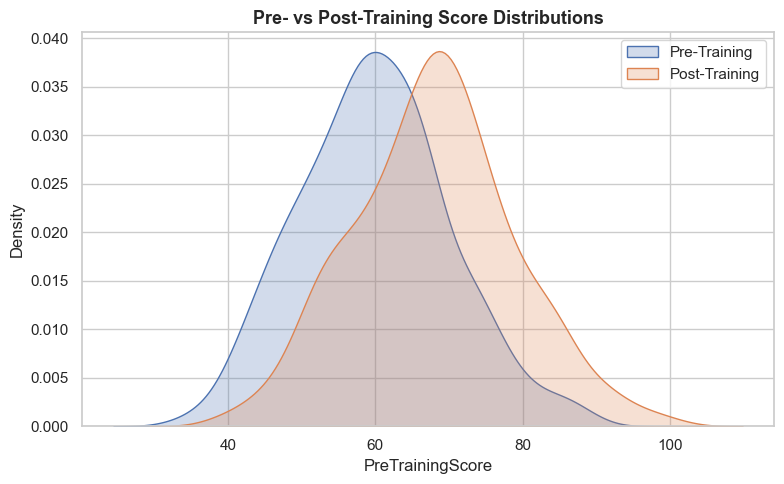

In [32]:
# H0: mean difference between Post- and Pre-training scores is 0 (no improvement)
# H1: mean difference is not 0 (training had an effect)
pre = df["PreTrainingScore"]
post = df["PostTrainingScore"]
diff = post - pre

t_stat, p_value = stats.ttest_rel(post, pre)

print(f"Mean Pre-Training Score:  {pre.mean():.2f}")
print(f"Mean Post-Training Score: {post.mean():.2f}")
print(f"Mean improvement:         {diff.mean():.2f}")
print(f"Paired t-test: t-statistic = {t_stat:.3f}, p-value = {p_value:.6f}")
print("Conclusion:", "Reject H0 - training produced a statistically significant improvement."
      if p_value < 0.05 else "Fail to reject H0 - no significant improvement detected.")

fig, ax = plt.subplots()
sns.kdeplot(pre, label="Pre-Training", fill=True, ax=ax)
sns.kdeplot(post, label="Post-Training", fill=True, ax=ax)
ax.set_title("Pre- vs Post-Training Score Distributions")
ax.legend()
plt.tight_layout(); plt.show()


## 12. Analysis of Variance (ANOVA)

ANOVA extends the t-test to **three or more groups**, testing whether at least one group mean
differs from the others.

- **One-way ANOVA**: one categorical factor (Department) affecting one numeric outcome (PerformanceScore).
- **Two-way ANOVA**: two categorical factors (Department and Gender) plus their interaction.
- If ANOVA is significant, a **post-hoc test** (Tukey HSD) identifies which specific pairs of groups differ.


In [33]:
# 12.1 One-way ANOVA: does PerformanceScore differ across Departments?
groups = [df.loc[df["Department"] == d, "PerformanceScore"] for d in df["Department"].unique()]
f_stat, p_value = stats.f_oneway(*groups)

print("One-way ANOVA: PerformanceScore ~ Department")
print(f"F-statistic = {f_stat:.3f}, p-value = {p_value:.6f}")
print("Conclusion:", "Reject H0 - at least one department's mean performance differs."
      if p_value < 0.05 else "Fail to reject H0 - no significant difference across departments.")

print("\nGroup means:")
print(df.groupby("Department")["PerformanceScore"].mean().round(2))


One-way ANOVA: PerformanceScore ~ Department
F-statistic = 14.331, p-value = 0.000000
Conclusion: Reject H0 - at least one department's mean performance differs.

Group means:
Department
Engineering    85.87
Marketing      78.25
Operations     78.08
Sales          80.96
Name: PerformanceScore, dtype: float64


In [34]:
# 12.2 Post-hoc Tukey HSD test - pinpoints which specific department pairs differ significantly
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(endog=df["PerformanceScore"], groups=df["Department"], alpha=0.05)
print(tukey_result)


     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1     group2   meandiff p-adj   lower    upper  reject
--------------------------------------------------------------
Engineering  Marketing  -7.6201    0.0 -11.2304 -4.0098   True
Engineering Operations  -7.7907    0.0 -11.4871 -4.0944   True
Engineering      Sales  -4.9096 0.0006  -8.1401  -1.679   True
  Marketing Operations  -0.1706 0.9995  -4.2137  3.8725  False
  Marketing      Sales   2.7105 0.2169  -0.9116  6.3327  False
 Operations      Sales   2.8812 0.1879  -0.8268  6.5891  False
--------------------------------------------------------------


In [35]:
# 12.3 Two-way ANOVA: PerformanceScore ~ Department + Gender + Department:Gender (interaction)
# Built with the statsmodels formula API and an ANOVA (Type II) table
model = smf.ols("PerformanceScore ~ C(Department) + C(Gender) + C(Department):C(Gender)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table


,sum_sq,df,F,PR(>F)
C(Department),4068.396096,3.0,14.286232,7.478953e-09
C(Gender),425.063960,1.0,4.477855,3.496666e-02
C(Department):C(Gender),236.146821,3.0,0.829233,4.783718e-01
Residual,37210.913760,392.0,NaN,NaN


**Reading the two-way ANOVA table:** the `PR(>F)` column is the p-value for each term. A
department main effect below 0.05 means departments differ on average; a gender main effect below
0.05 means genders differ on average; a significant interaction term would mean the department effect
depends on gender (or vice versa).

## 13. Non-Parametric Tests

Non-parametric tests make no assumption about the underlying distribution (e.g. normality) and are
used when that assumption is violated, or the data is ordinal/ranked.

| Parametric test | Non-parametric equivalent |
|---|---|
| Independent two-sample t-test | Mann-Whitney U test |
| Paired t-test | Wilcoxon signed-rank test |
| One-way ANOVA | Kruskal-Wallis H test |


In [36]:
# 13.1 Mann-Whitney U test - non-parametric alternative to the independent t-test
u_stat, p_value = stats.mannwhitneyu(male_scores, female_scores, alternative="two-sided")
print("Mann-Whitney U test (Male vs Female PerformanceScore)")
print(f"U-statistic = {u_stat:.1f}, p-value = {p_value:.5f}")
print("Conclusion:", "Reject H0." if p_value < 0.05 else "Fail to reject H0.")


Mann-Whitney U test (Male vs Female PerformanceScore)
U-statistic = 17417.5, p-value = 0.02963
Conclusion: Reject H0.


In [37]:
# 13.2 Wilcoxon signed-rank test - non-parametric alternative to the paired t-test
w_stat, p_value = stats.wilcoxon(post, pre)
print("Wilcoxon signed-rank test (Post vs Pre training scores)")
print(f"W-statistic = {w_stat:.1f}, p-value = {p_value:.6f}")
print("Conclusion:", "Reject H0 - training produced a significant improvement." if p_value < 0.05
      else "Fail to reject H0.")


Wilcoxon signed-rank test (Post vs Pre training scores)
W-statistic = 97.0, p-value = 0.000000
Conclusion: Reject H0 - training produced a significant improvement.


In [38]:
# 13.3 Kruskal-Wallis H test - non-parametric alternative to one-way ANOVA
h_stat, p_value = stats.kruskal(*groups)
print("Kruskal-Wallis H test (PerformanceScore across Departments)")
print(f"H-statistic = {h_stat:.3f}, p-value = {p_value:.6f}")
print("Conclusion:", "Reject H0 - at least one department differs." if p_value < 0.05
      else "Fail to reject H0.")


Kruskal-Wallis H test (PerformanceScore across Departments)
H-statistic = 41.098, p-value = 0.000000
Conclusion: Reject H0 - at least one department differs.


## 14. Tests of Normality and Equal Variance

Many parametric tests (t-tests, ANOVA, Pearson correlation) assume the data is approximately
normally distributed and that group variances are roughly equal. We test both assumptions formally.


In [39]:
# 14.1 Normality tests on PerformanceScore
shapiro_stat, shapiro_p = stats.shapiro(df["PerformanceScore"])
ks_stat, ks_p = stats.kstest(df["PerformanceScore"], "norm",
                              args=(df["PerformanceScore"].mean(), df["PerformanceScore"].std()))
dagostino_stat, dagostino_p = stats.normaltest(df["PerformanceScore"])
anderson_result = stats.anderson(df["PerformanceScore"], dist="norm")

print("Normality tests on PerformanceScore (H0: data is normally distributed)")
print(f"Shapiro-Wilk:        statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
print(f"Kolmogorov-Smirnov:  statistic={ks_stat:.4f}, p-value={ks_p:.4f}")
print(f"D'Agostino K^2:      statistic={dagostino_stat:.4f}, p-value={dagostino_p:.4f}")
print(f"Anderson-Darling:    statistic={anderson_result.statistic:.4f} "
      f"(critical value at 5% = {anderson_result.critical_values[2]:.4f})")
print()
print("Rule of thumb: with n=400, Shapiro-Wilk is the most reliable of these tests for this sample size.")


Normality tests on PerformanceScore (H0: data is normally distributed)
Shapiro-Wilk:        statistic=0.9804, p-value=0.0000
Kolmogorov-Smirnov:  statistic=0.0422, p-value=0.4621
D'Agostino K^2:      statistic=18.1559, p-value=0.0001
Anderson-Darling:    statistic=1.5051 (critical value at 5% = 0.7790)

Rule of thumb: with n=400, Shapiro-Wilk is the most reliable of these tests for this sample size.


In [40]:
# 14.2 Equal-variance (homogeneity of variance) tests across Departments
levene_stat, levene_p = stats.levene(*groups)                 # robust to non-normality
bartlett_stat, bartlett_p = stats.bartlett(*groups)            # assumes normality, more powerful if met

print("Levene's test (robust):  statistic={:.3f}, p-value={:.4f}".format(levene_stat, levene_p))
print("Bartlett's test:         statistic={:.3f}, p-value={:.4f}".format(bartlett_stat, bartlett_p))
print("H0 for both: all group variances are equal.")


Levene's test (robust):  statistic=0.312, p-value=0.8170
Bartlett's test:         statistic=0.655, p-value=0.8837
H0 for both: all group variances are equal.


## 15. Effect Size

A p-value tells you whether an effect is statistically significant; **effect size** tells you how
large that effect actually is - essential for practical interpretation, especially with big samples
where even tiny differences become "significant".

- **Cohen's d** - standardised mean difference, used with t-tests.
- **Eta-squared (η²)** - proportion of variance explained, used with ANOVA.


In [41]:
# 15.1 Cohen's d for the Male vs Female PerformanceScore comparison
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.std(ddof=1)**2 + (ny - 1) * y.std(ddof=1)**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std

d = cohens_d(male_scores, female_scores)
print(f"Cohen's d (Male vs Female PerformanceScore) = {d:.3f}")
print("Rule of thumb: 0.2 = small, 0.5 = medium, 0.8 = large effect.")


Cohen's d (Male vs Female PerformanceScore) = -0.212
Rule of thumb: 0.2 = small, 0.5 = medium, 0.8 = large effect.


In [42]:
# 15.2 Eta-squared for the one-way ANOVA (Department -> PerformanceScore)
grand_mean = df["PerformanceScore"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total = ((df["PerformanceScore"] - grand_mean)**2).sum()
eta_squared = ss_between / ss_total

print(f"Eta-squared (Department -> PerformanceScore) = {eta_squared:.3f}")
print("Rule of thumb: 0.01 = small, 0.06 = medium, 0.14 = large effect.")


Eta-squared (Department -> PerformanceScore) = 0.098
Rule of thumb: 0.01 = small, 0.06 = medium, 0.14 = large effect.


## 16. Correlation Analysis

Correlation measures the strength and direction of a relationship between two numeric variables.

- **Pearson's r** - linear relationships, assumes roughly normal, continuous data.
- **Spearman's rho** - monotonic relationships based on ranks, robust to outliers and non-normal data.
- **Kendall's tau** - also rank-based, more robust with small samples or many tied ranks.

Correlation coefficients range from -1 (perfect negative) to +1 (perfect positive); 0 means no
linear/monotonic relationship. **Correlation does not imply causation.**


In [43]:
x = df["YearsExperience"]
y = df["PerformanceScore"]

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)
kendall_tau, kendall_p = stats.kendalltau(x, y)

print("Correlation between YearsExperience and PerformanceScore")
print(f"Pearson's r  = {pearson_r:.3f}  (p={pearson_p:.5f})")
print(f"Spearman rho = {spearman_r:.3f}  (p={spearman_p:.5f})")
print(f"Kendall tau  = {kendall_tau:.3f}  (p={kendall_p:.5f})")


Correlation between YearsExperience and PerformanceScore
Pearson's r  = 0.532  (p=0.00000)
Spearman rho = 0.517  (p=0.00000)
Kendall tau  = 0.361  (p=0.00000)


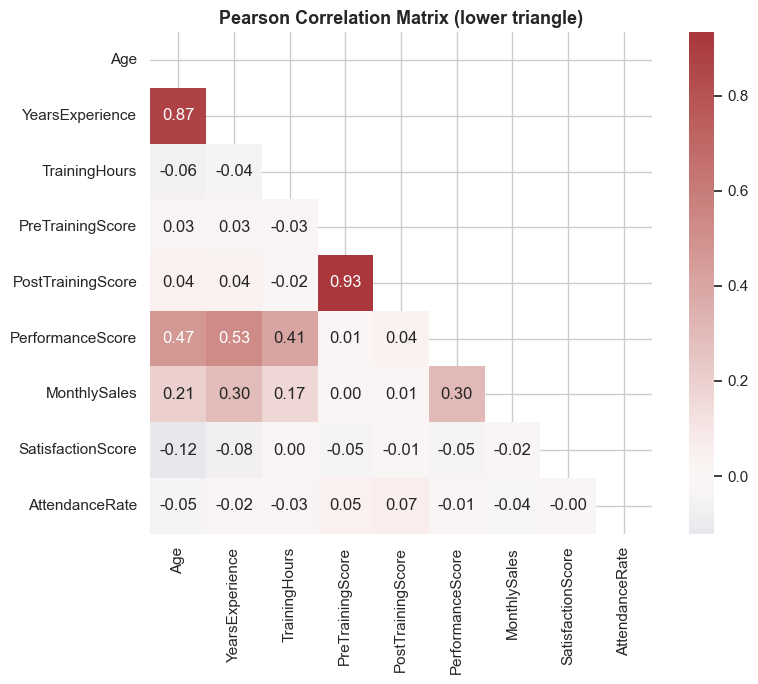

In [44]:
# Full Pearson correlation matrix with a mask hiding the redundant upper triangle
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Pearson Correlation Matrix (lower triangle)")
plt.tight_layout(); plt.show()


## 17. Chi-Square Tests for Categorical Data

- **Chi-square test of independence**: are two categorical variables associated?
- **Chi-square goodness-of-fit test**: does an observed categorical distribution match an expected one?
- **Cramer's V**: effect size for the test of independence (0 = no association, 1 = perfect association).


In [45]:
# 17.1 Chi-square test of independence: Region vs Promoted
contingency = pd.crosstab(df["Region"], df["Promoted"])
print("Contingency table (observed counts):")
print(contingency)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic = {chi2_stat:.3f}, degrees of freedom = {dof}, p-value = {p_value:.5f}")
print("Conclusion:", "Reject H0 - Region and Promotion status are associated." if p_value < 0.05
      else "Fail to reject H0 - no significant association detected.")

# Cramer's V effect size
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim))
print(f"Cramer's V (effect size) = {cramers_v:.3f}")


Contingency table (observed counts):
Promoted   0   1
Region          
North     57  99
South     49  86
West      42  67

Chi-square statistic = 0.153, degrees of freedom = 2, p-value = 0.92649
Conclusion: Fail to reject H0 - no significant association detected.
Cramer's V (effect size) = 0.020


In [46]:
# 17.2 Chi-square goodness-of-fit test: does the observed Education split match an assumed 15/45/30/10 split?
observed_counts = df["Education"].value_counts().reindex(["Diploma", "Bachelors", "Masters", "PhD"]).values
expected_props = np.array([0.15, 0.45, 0.30, 0.10])
expected_counts = expected_props * observed_counts.sum()

chi2_stat, p_value = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
print("Observed counts:", dict(zip(["Diploma", "Bachelors", "Masters", "PhD"], observed_counts)))
print("Expected counts:", dict(zip(["Diploma", "Bachelors", "Masters", "PhD"], expected_counts.round(1))))
print(f"\nChi-square statistic = {chi2_stat:.3f}, p-value = {p_value:.5f}")
print("Conclusion:", "Reject H0 - the observed split differs from the assumed split." if p_value < 0.05
      else "Fail to reject H0 - observed split is consistent with the assumed split.")


Observed counts: {'Diploma': np.int64(54), 'Bachelors': np.int64(198), 'Masters': np.int64(104), 'PhD': np.int64(44)}
Expected counts: {'Diploma': np.float64(60.0), 'Bachelors': np.float64(180.0), 'Masters': np.float64(120.0), 'PhD': np.float64(40.0)}

Chi-square statistic = 4.933, p-value = 0.17674
Conclusion: Fail to reject H0 - observed split is consistent with the assumed split.


## 18. Simple and Multiple Linear Regression

Linear regression models a numeric outcome as a linear combination of one or more predictors:

$$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \varepsilon $$

We fit models with `statsmodels` (for full inferential statistics - coefficients, standard errors,
p-values, R²) and cross-check the coefficients with `scikit-learn`.


In [47]:
# 18.1 Simple linear regression: PerformanceScore ~ YearsExperience
simple_model = smf.ols("PerformanceScore ~ YearsExperience", data=df).fit()
print(simple_model.summary())


                            OLS Regression Results                            
Dep. Variable:       PerformanceScore   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     157.1
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.30e-30
Time:                        21:37:00   Log-Likelihood:                -1431.7
No. Observations:                 400   AIC:                             2867.
Df Residuals:                     398   BIC:                             2875.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          71.7558      0.882     

**Reading this table, line by line:**
- `coef` for `YearsExperience` - the predicted change in PerformanceScore for each extra year of experience.
- `P>|t|` - p-value for each coefficient; below 0.05 means that predictor is statistically significant.
- `R-squared` - proportion of variance in PerformanceScore explained by YearsExperience alone.
- `F-statistic` / `Prob (F-statistic)` - tests whether the model as a whole explains significant variance.


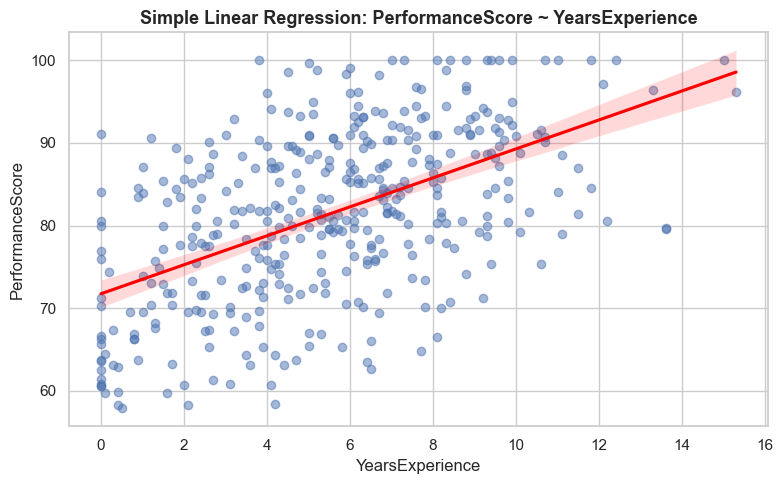

In [48]:
# Visualise the fitted regression line against the actual data
fig, ax = plt.subplots()
sns.regplot(data=df, x="YearsExperience", y="PerformanceScore",
            scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Simple Linear Regression: PerformanceScore ~ YearsExperience")
plt.tight_layout(); plt.show()


In [49]:
# 18.2 Multiple linear regression: PerformanceScore ~ YearsExperience + TrainingHours + AttendanceRate + C(Department)
multi_model = smf.ols(
    "PerformanceScore ~ YearsExperience + TrainingHours + AttendanceRate + C(Department)",
    data=df
).fit()
print(multi_model.summary())


                            OLS Regression Results                            
Dep. Variable:       PerformanceScore   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     80.57
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           2.17e-65
Time:                        21:37:01   Log-Likelihood:                -1337.9
No. Observations:                 400   AIC:                             2690.
Df Residuals:                     393   BIC:                             2718.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [50]:
# 18.3 Cross-checking coefficients with scikit-learn's LinearRegression
X = df[["YearsExperience", "TrainingHours", "AttendanceRate"]]
y = df["PerformanceScore"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
y_pred = sk_model.predict(X_test)

print("scikit-learn coefficients:")
for name, coef in zip(X.columns, sk_model.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"  Intercept: {sk_model.intercept_:.4f}")

print(f"\nTest-set R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Test-set RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


scikit-learn coefficients:
  YearsExperience: 1.7649
  TrainingHours: 0.4160
  AttendanceRate: -0.0246
  Intercept: 57.1214

Test-set R-squared: 0.4389
Test-set RMSE:      7.9297


## 19. Regression Diagnostics and Multicollinearity

A regression model is only as trustworthy as its assumptions:

1. **Linearity** - checked visually via residual plots.
2. **Homoscedasticity** (constant residual variance) - checked via a residuals-vs-fitted plot and the
   Breusch-Pagan test.
3. **Normality of residuals** - checked via a Q-Q plot of residuals.
4. **No severe multicollinearity** - checked via the Variance Inflation Factor (VIF); VIF > 10 signals
   a problem.


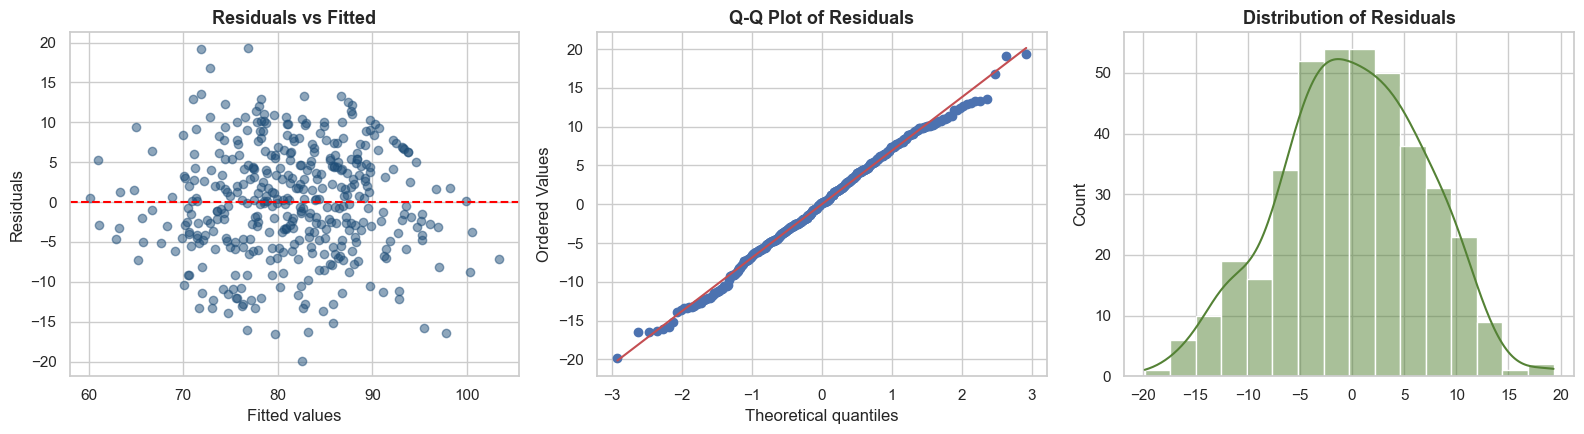

In [51]:
fitted_vals = multi_model.fittedvalues
residuals = multi_model.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 19.1 Residuals vs Fitted - should show a random cloud around zero (no pattern = good)
axes[0].scatter(fitted_vals, residuals, alpha=0.5, color="#1F4E78")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# 19.2 Q-Q plot of residuals - checks normality of residuals
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

# 19.3 Histogram of residuals
sns.histplot(residuals, kde=True, ax=axes[2], color="#548235")
axes[2].set_title("Distribution of Residuals")

plt.tight_layout(); plt.show()


In [52]:
# 19.4 Breusch-Pagan test for heteroscedasticity (H0: residual variance is constant)
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(residuals, multi_model.model.exog)
print(f"Breusch-Pagan test: LM statistic = {bp_stat:.3f}, p-value = {bp_pvalue:.4f}")
print("Conclusion:", "Reject H0 - evidence of heteroscedasticity." if bp_pvalue < 0.05
      else "Fail to reject H0 - residual variance appears constant (homoscedastic).")


Breusch-Pagan test: LM statistic = 4.022, p-value = 0.6736
Conclusion: Fail to reject H0 - residual variance appears constant (homoscedastic).


In [53]:
# 19.5 Variance Inflation Factor (VIF) - detects multicollinearity among predictors
X_vif = sm.add_constant(df[["YearsExperience", "TrainingHours", "AttendanceRate"]])
vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data = vif_data[vif_data["feature"] != "const"]
vif_data


,feature,VIF
1,YearsExperience,1.002449
2,TrainingHours,1.003050
3,AttendanceRate,1.001441


All VIF values well below 10 (typically below 5) indicate the predictors are not problematically
collinear, so each coefficient in the multiple regression can be interpreted on its own.

## 20. Logistic Regression

Used when the outcome is **binary** (here, `Promoted`: 0 or 1). Logistic regression models the
log-odds of the outcome as a linear function of the predictors, and predicted probabilities are
squeezed into [0, 1] via the sigmoid function.


In [54]:
# 20.1 Logistic regression with statsmodels - full inferential output (coefficients, p-values, odds ratios)
logit_model = smf.logit("Promoted ~ YearsExperience + PerformanceScore + TrainingHours", data=df).fit(disp=0)
print(logit_model.summary())

print("\nOdds ratios (exp(coefficient)):")
print(np.exp(logit_model.params))


                           Logit Regression Results                           
Dep. Variable:               Promoted   No. Observations:                  400
Model:                          Logit   Df Residuals:                      396
Method:                           MLE   Df Model:                            3
Date:                Fri, 28 Aug 2026   Pseudo R-squ.:                  0.2136
Time:                        21:37:03   Log-Likelihood:                -207.27
converged:                       True   LL-Null:                       -263.58
Covariance Type:            nonrobust   LLR p-value:                 3.001e-24
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -5.0340      1.057     -4.761      0.000      -7.106      -2.962
YearsExperience      0.3397      0.054      6.245      0.000       0.233       0.446
PerformanceScore     0.0310 

**Interpreting an odds ratio:** a value above 1 means an increase in that predictor is associated
with higher odds of promotion; a value below 1 means the opposite. For example, an odds ratio of 1.15 on
`YearsExperience` means each extra year of experience is associated with a 15% increase in the odds of
being promoted, holding the other predictors constant.

In [55]:
# 20.2 Logistic regression with scikit-learn, plus a full classification evaluation
X = df[["YearsExperience", "PerformanceScore", "TrainingHours"]]
y = df["Promoted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.690

Confusion Matrix:
[[17 20]
 [11 52]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.46      0.52        37
           1       0.72      0.83      0.77        63

    accuracy                           0.69       100
   macro avg       0.66      0.64      0.65       100
weighted avg       0.68      0.69      0.68       100



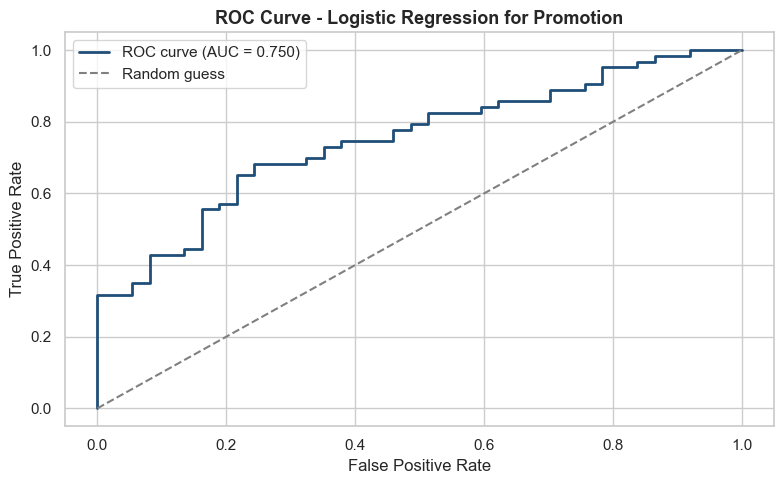

In [56]:
# 20.3 ROC curve and AUC - overall discrimination ability of the classifier across all thresholds
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color="#1F4E78", lw=2, label=f"ROC curve (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Logistic Regression for Promotion")
ax.legend()
plt.tight_layout(); plt.show()


## 21. Statistical Power and Sample Size

- **Statistical power** is the probability of correctly rejecting a false null hypothesis (avoiding a
  Type II error). Conventionally, 0.80 (80%) is considered adequate.
- **Power analysis** answers two practical questions: "how large a sample do I need to detect an effect
  of a given size?" and "what power did my study actually have?"


In [57]:
power_analysis = TTestIndPower()

# 21.1 Required sample size to detect a medium effect (Cohen's d = 0.5) with 80% power, alpha = 0.05
required_n = power_analysis.solve_power(effect_size=0.5, alpha=0.05, power=0.80, ratio=1.0)
print(f"Required sample size PER GROUP to detect d=0.5 at alpha=0.05, power=0.80: {required_n:.1f}")

# 21.2 Achieved power of our actual Male-vs-Female PerformanceScore comparison
observed_d = cohens_d(male_scores, female_scores)
achieved_power = power_analysis.solve_power(
    effect_size=abs(observed_d), nobs1=len(male_scores), alpha=0.05, ratio=len(female_scores)/len(male_scores)
)
print(f"Observed effect size (Cohen's d) = {observed_d:.3f}")
print(f"Achieved statistical power of our Male vs Female comparison = {achieved_power:.3f}")


Required sample size PER GROUP to detect d=0.5 at alpha=0.05, power=0.80: 63.8
Observed effect size (Cohen's d) = -0.212
Achieved statistical power of our Male vs Female comparison = 0.561


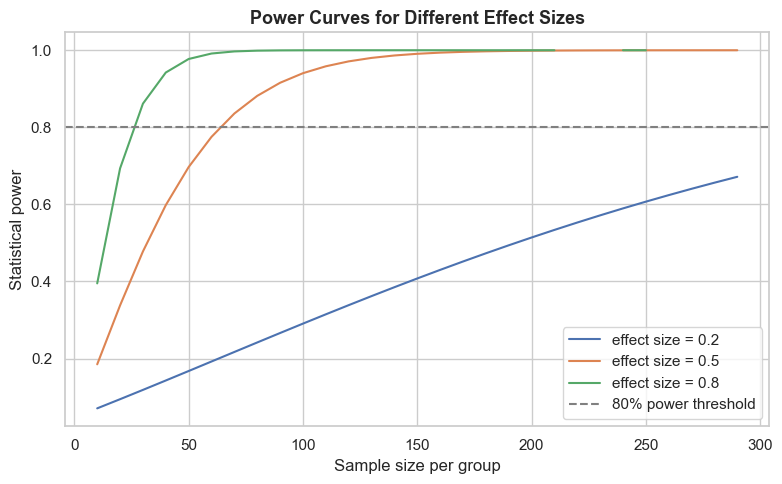

In [58]:
# 21.3 Power curve: how power changes with sample size, for a few effect sizes
sample_sizes = np.arange(10, 300, 10)
fig, ax = plt.subplots()
for effect in [0.2, 0.5, 0.8]:
    powers = [power_analysis.solve_power(effect_size=effect, nobs1=n, alpha=0.05) for n in sample_sizes]
    ax.plot(sample_sizes, powers, label=f"effect size = {effect}")
ax.axhline(0.8, color="gray", linestyle="--", label="80% power threshold")
ax.set_xlabel("Sample size per group"); ax.set_ylabel("Statistical power")
ax.set_title("Power Curves for Different Effect Sizes")
ax.legend()
plt.tight_layout(); plt.show()


## 22. Bootstrapping and Resampling

Bootstrapping estimates the sampling distribution of a statistic by repeatedly **resampling with
replacement** from the observed data. It requires no distributional assumptions and works for almost
any statistic (mean, median, correlation, regression coefficient, etc.).


Observed median MonthlySales: 6269.75
Bootstrap 95% CI for the median: (6125.75, 6467.86)


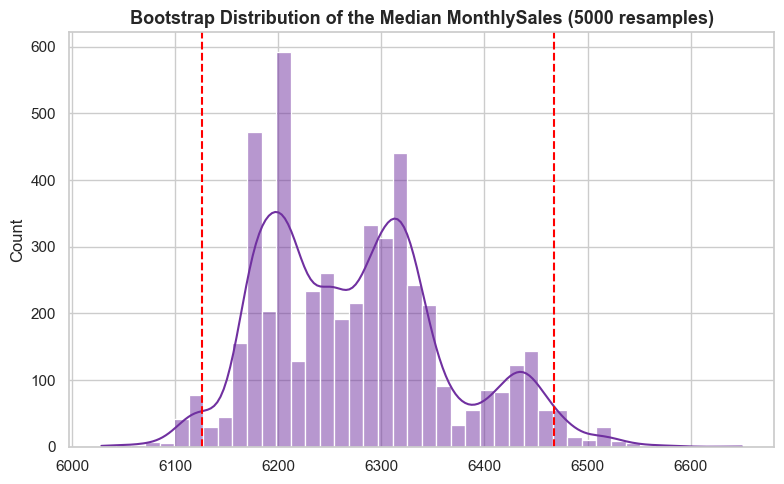

In [59]:
# 22.1 Bootstrap confidence interval for the median of MonthlySales (robust to the outliers we injected)
n_bootstrap = 5000
bootstrap_medians = np.empty(n_bootstrap)

data = df["MonthlySales"].values
for i in range(n_bootstrap):
    resample = RNG.choice(data, size=len(data), replace=True)
    bootstrap_medians[i] = np.median(resample)

ci_lower, ci_upper = np.percentile(bootstrap_medians, [2.5, 97.5])

print(f"Observed median MonthlySales: {np.median(data):.2f}")
print(f"Bootstrap 95% CI for the median: ({ci_lower:.2f}, {ci_upper:.2f})")

fig, ax = plt.subplots()
sns.histplot(bootstrap_medians, kde=True, ax=ax, color="#7030A0")
ax.axvline(ci_lower, color="red", linestyle="--")
ax.axvline(ci_upper, color="red", linestyle="--")
ax.set_title(f"Bootstrap Distribution of the Median MonthlySales ({n_bootstrap} resamples)")
plt.tight_layout(); plt.show()


In [60]:
# 22.2 Bootstrap hypothesis test: is the difference in mean PerformanceScore (Male - Female) real?
observed_diff = male_scores.mean() - female_scores.mean()

combined = np.concatenate([male_scores.values, female_scores.values])
n_male = len(male_scores)
n_boot = 5000
boot_diffs = np.empty(n_boot)

for i in range(n_boot):
    shuffled = RNG.permutation(combined)
    boot_diffs[i] = shuffled[:n_male].mean() - shuffled[n_male:].mean()

# Two-sided permutation p-value: how often does a random relabelling produce a difference
# at least as extreme as the one we actually observed?
p_value_perm = np.mean(np.abs(boot_diffs) >= np.abs(observed_diff))
print(f"Observed difference in means (Male - Female): {observed_diff:.3f}")
print(f"Permutation-test p-value: {p_value_perm:.4f}")
print("Conclusion:", "Reject H0 (matches the parametric t-test result)." if p_value_perm < 0.05
      else "Fail to reject H0.")


Observed difference in means (Male - Female): -2.168
Permutation-test p-value: 0.0354
Conclusion: Reject H0 (matches the parametric t-test result).


## 23. Bayesian Statistics - A Practical Introduction

Bayesian statistics updates a **prior belief** about a parameter with observed data to produce a
**posterior belief**, using Bayes' theorem:

$$ P(\theta \mid \text{data}) = \frac{P(\text{data} \mid \theta) \, P(\theta)}{P(\text{data})} $$

For a proportion (like the promotion rate), the Beta distribution is the natural "conjugate prior":
starting with a Beta prior and observing binomial data yields a Beta posterior in closed form.


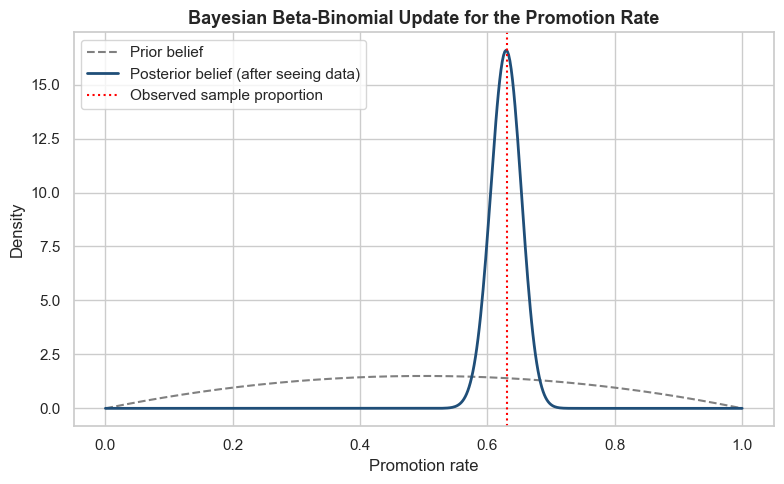

Posterior mean estimate of the promotion rate: 0.629
95% credible interval: (0.581, 0.675)


In [61]:
# 23.1 Bayesian estimation of the promotion rate using a Beta-Binomial conjugate model
prior_alpha, prior_beta = 2, 2   # a mild, weakly-informative prior centred on 0.5

successes = df["Promoted"].sum()
failures = len(df) - successes

posterior_alpha = prior_alpha + successes
posterior_beta = prior_beta + failures

x = np.linspace(0, 1, 500)
prior_pdf = stats.beta.pdf(x, prior_alpha, prior_beta)
posterior_pdf = stats.beta.pdf(x, posterior_alpha, posterior_beta)

fig, ax = plt.subplots()
ax.plot(x, prior_pdf, label="Prior belief", color="gray", linestyle="--")
ax.plot(x, posterior_pdf, label="Posterior belief (after seeing data)", color="#1F4E78", lw=2)
ax.axvline(successes / len(df), color="red", linestyle=":", label="Observed sample proportion")
ax.set_xlabel("Promotion rate"); ax.set_ylabel("Density")
ax.set_title("Bayesian Beta-Binomial Update for the Promotion Rate")
ax.legend()
plt.tight_layout(); plt.show()

posterior_mean = posterior_alpha / (posterior_alpha + posterior_beta)
credible_interval = stats.beta.interval(0.95, posterior_alpha, posterior_beta)
print(f"Posterior mean estimate of the promotion rate: {posterior_mean:.3f}")
print(f"95% credible interval: ({credible_interval[0]:.3f}, {credible_interval[1]:.3f})")


**Confidence interval vs. credible interval:** a 95% frequentist confidence interval means
"95% of intervals built this way, across repeated sampling, would contain the true value." A 95%
Bayesian credible interval means "given the data and prior, there is a 95% probability the true value
lies in this range" - a more direct and often more intuitive statement.

## 24. Time Series Analysis

We switch to the second dataset, `monthly_revenue_timeseries.csv`, to cover time-series-specific
statistics: trend/seasonality decomposition, autocorrelation, and stationarity testing.


In [62]:
ts = pd.read_csv("monthly_revenue_timeseries.csv", parse_dates=["Date"])
ts = ts.set_index("Date")
ts.index.freq = "MS"   # tell pandas/statsmodels this is a monthly-start series
ts.head()


,MonthlyRevenue,MarketingSpend,UnitsSold
Date,,,
2020-01-01,15802.19,2001.85,393
2020-02-01,16186.81,2272.19,379
2020-03-01,17881.72,2501.13,403
2020-04-01,17799.53,2551.06,427
2020-05-01,17581.83,2400.32,391


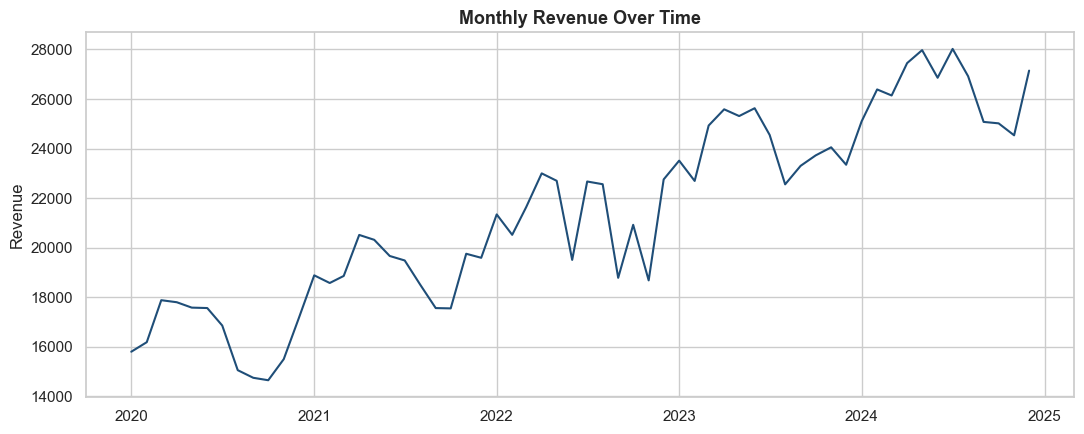

In [63]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(ts.index, ts["MonthlyRevenue"], color="#1F4E78")
ax.set_title("Monthly Revenue Over Time")
ax.set_ylabel("Revenue")
plt.tight_layout(); plt.show()


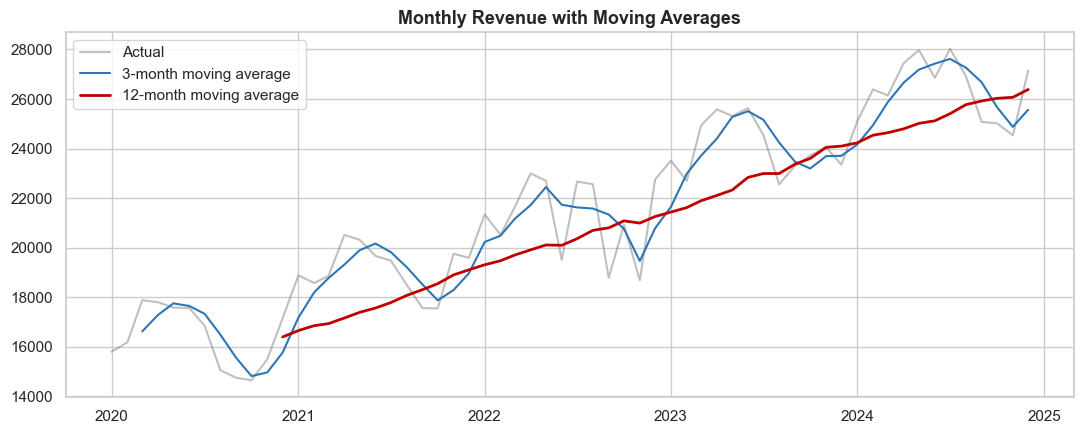

In [64]:
# 24.1 Moving average smoothing - a simple way to visualise the underlying trend
ts["MA_3"] = ts["MonthlyRevenue"].rolling(window=3).mean()
ts["MA_12"] = ts["MonthlyRevenue"].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(ts.index, ts["MonthlyRevenue"], label="Actual", alpha=0.5, color="gray")
ax.plot(ts.index, ts["MA_3"], label="3-month moving average", color="#2E75B6")
ax.plot(ts.index, ts["MA_12"], label="12-month moving average", color="#C00000", lw=2)
ax.set_title("Monthly Revenue with Moving Averages")
ax.legend()
plt.tight_layout(); plt.show()


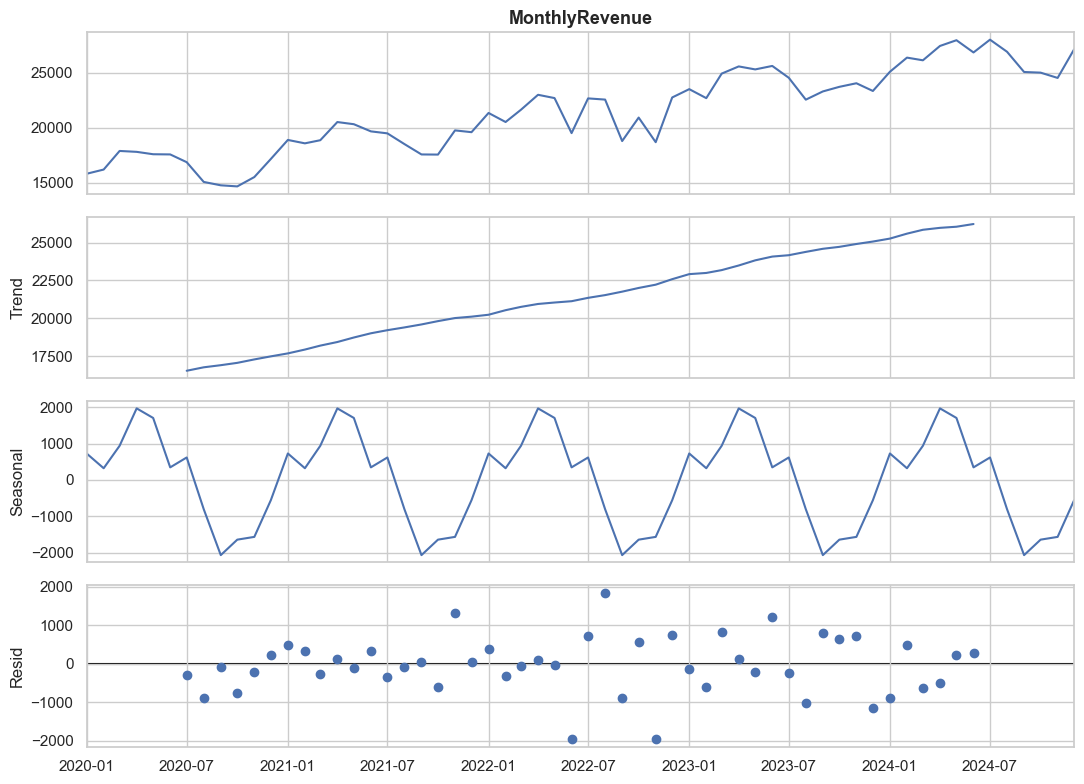

In [65]:
# 24.2 Classical decomposition into Trend, Seasonal, and Residual components
decomposition = seasonal_decompose(ts["MonthlyRevenue"], model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(11, 8)
plt.tight_layout(); plt.show()


In [66]:
# 24.3 Augmented Dickey-Fuller (ADF) test for stationarity
# H0: the series has a unit root (i.e. it is NON-stationary)
adf_stat, adf_p, used_lag, n_obs, crit_values, icbest = adfuller(ts["MonthlyRevenue"])
print(f"ADF statistic = {adf_stat:.3f}, p-value = {adf_p:.4f}")
print("Critical values:", {k: round(v, 3) for k, v in crit_values.items()})
print("Conclusion:", "Reject H0 - the series is stationary." if adf_p < 0.05
      else "Fail to reject H0 - the series is likely non-stationary (has trend/seasonality), "
           "consistent with what we see in the decomposition above.")


ADF statistic = -0.728, p-value = 0.8393
Critical values: {'1%': np.float64(-3.571), '5%': np.float64(-2.923), '10%': np.float64(-2.599)}
Conclusion: Fail to reject H0 - the series is likely non-stationary (has trend/seasonality), consistent with what we see in the decomposition above.


ADF test on first-differenced series: statistic=-5.601, p-value=0.0000
Conclusion: Now stationary after differencing.


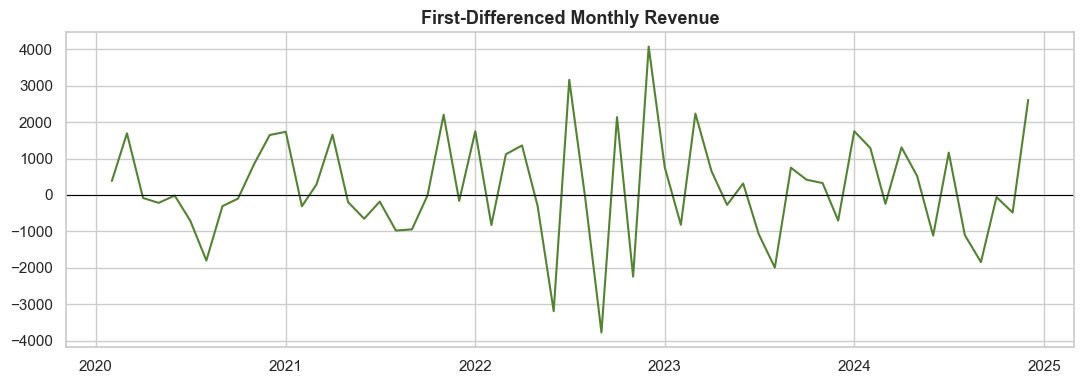

In [67]:
# 24.4 Differencing to achieve stationarity when a series is non-stationary
ts["Revenue_diff"] = ts["MonthlyRevenue"].diff()

adf_stat2, adf_p2, *_ = adfuller(ts["Revenue_diff"].dropna())
print(f"ADF test on first-differenced series: statistic={adf_stat2:.3f}, p-value={adf_p2:.4f}")
print("Conclusion:", "Now stationary after differencing." if adf_p2 < 0.05 else "Still non-stationary.")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts.index, ts["Revenue_diff"], color="#548235")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("First-Differenced Monthly Revenue")
plt.tight_layout(); plt.show()


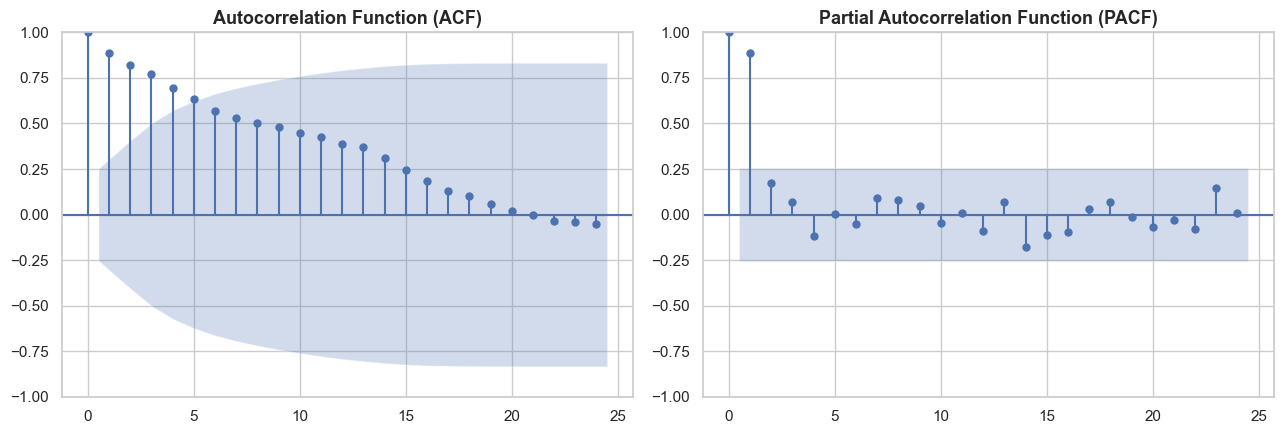

In [68]:
# 24.5 Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots
# ACF: correlation of the series with its own lagged values.
# PACF: correlation of the series with a lag, after removing the effect of shorter lags.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_acf(ts["MonthlyRevenue"], lags=24, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(ts["MonthlyRevenue"], lags=24, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout(); plt.show()


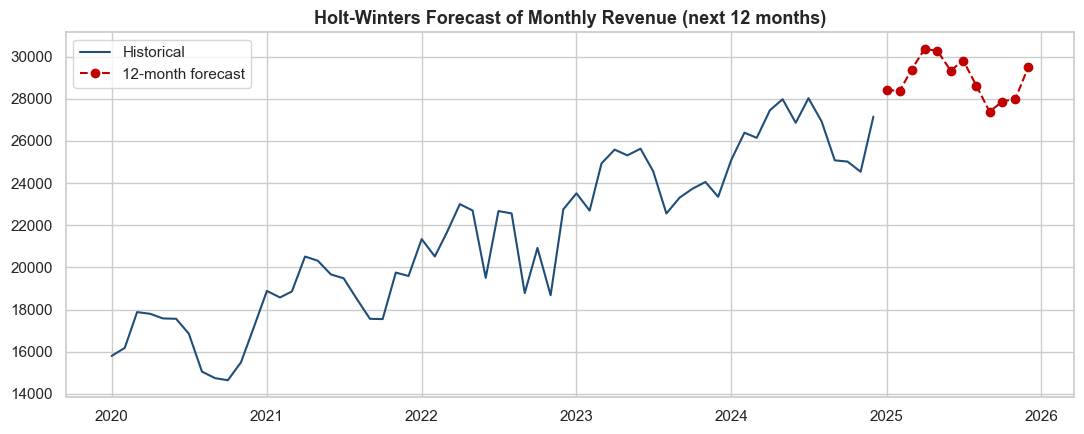

2025-01-01    28420.03
2025-02-01    28364.02
2025-03-01    29382.39
2025-04-01    30361.43
2025-05-01    30268.85
2025-06-01    29336.51
2025-07-01    29809.30
2025-08-01    28612.24
2025-09-01    27387.04
2025-10-01    27864.91
2025-11-01    27996.34
2025-12-01    29489.94
Freq: MS, dtype: float64

In [69]:
# 24.6 A simple forecast using Holt-Winters Exponential Smoothing (level + trend + seasonality)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    ts["MonthlyRevenue"], trend="add", seasonal="add", seasonal_periods=12
).fit()

forecast_horizon = 12
forecast = hw_model.forecast(forecast_horizon)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(ts.index, ts["MonthlyRevenue"], label="Historical", color="#1F4E78")
ax.plot(forecast.index, forecast, label="12-month forecast", color="#C00000", linestyle="--", marker="o")
ax.set_title("Holt-Winters Forecast of Monthly Revenue (next 12 months)")
ax.legend()
plt.tight_layout(); plt.show()

forecast.round(2)


## 25. Cheat Sheet and Reference Summary

| Goal | Test / Method | Python function |
|---|---|---|
| Summarise one numeric variable | Descriptive statistics | `Series.describe()`, `.mean()`, `.median()`, `.std()` |
| Compare one mean to a fixed value | One-sample t-test | `scipy.stats.ttest_1samp` |
| Compare two independent group means | Independent t-test | `scipy.stats.ttest_ind` |
| Compare two independent group means (non-normal) | Mann-Whitney U | `scipy.stats.mannwhitneyu` |
| Compare before/after on the same subjects | Paired t-test | `scipy.stats.ttest_rel` |
| Compare before/after (non-normal) | Wilcoxon signed-rank | `scipy.stats.wilcoxon` |
| Compare 3+ group means | One-way ANOVA | `scipy.stats.f_oneway`, `statsmodels.anova_lm` |
| Compare 3+ group means (non-normal) | Kruskal-Wallis | `scipy.stats.kruskal` |
| Which pairs differ after ANOVA | Tukey HSD | `statsmodels...pairwise_tukeyhsd` |
| Test two categorical variables for association | Chi-square independence | `scipy.stats.chi2_contingency` |
| Test if observed categories match expected | Chi-square goodness of fit | `scipy.stats.chisquare` |
| Test if data is normally distributed | Shapiro-Wilk / KS / Anderson-Darling | `scipy.stats.shapiro`, `.kstest`, `.anderson` |
| Test if group variances are equal | Levene's / Bartlett's test | `scipy.stats.levene`, `.bartlett` |
| Measure linear/monotonic relationship | Correlation | `scipy.stats.pearsonr`, `.spearmanr`, `.kendalltau` |
| Predict a numeric outcome | Linear regression | `statsmodels.formula.api.ols`, `sklearn.linear_model.LinearRegression` |
| Predict a binary outcome | Logistic regression | `statsmodels.formula.api.logit`, `sklearn.linear_model.LogisticRegression` |
| Check multicollinearity | Variance Inflation Factor | `statsmodels...variance_inflation_factor` |
| Estimate a statistic's uncertainty, assumption-free | Bootstrapping | manual resampling loop, shown above |
| Determine adequate sample size | Power analysis | `statsmodels.stats.power.TTestIndPower` |
| Decompose trend/seasonality in a time series | Seasonal decomposition | `statsmodels...seasonal_decompose` |
| Test if a time series is stationary | Augmented Dickey-Fuller | `statsmodels.tsa.stattools.adfuller` |
| Forecast a time series | Holt-Winters / ARIMA | `statsmodels.tsa.holtwinters.ExponentialSmoothing` |


## 26. Conclusion

This notebook walked through the full practical arc of statistical analytics in Python:

- **Descriptive statistics and visualization** to understand a dataset.
- **Probability distributions** to model uncertainty.
- **Inferential statistics** (confidence intervals, hypothesis tests, ANOVA, non-parametric tests,
  chi-square tests) to draw conclusions about a population from a sample.
- **Correlation and regression** (linear and logistic) to model relationships and make predictions.
- **Diagnostics** (normality, equal variance, multicollinearity, heteroscedasticity) to validate
  every assumption behind those models.
- **Effect size and power analysis** to judge practical significance and design better studies.
- **Bootstrapping and Bayesian methods** as modern, assumption-light alternatives to classical tests.
- **Time series analysis** to handle data that unfolds over time.

Use this notebook together with the companion Excel workbook, CSV files, Word document, and HTML
guide as a complete practical training kit.

---
**Prepared by: Kajola Gbenga**
**Data Scientist & AI Engineer**
